3.0 Data Understanding

3.1 Dataset Source

This project uses the Estimation of Obesity Levels Based on Eating Habits and Physical Condition dataset obtained from the UCI Machine Learning Repository. The dataset was developed to study how different lifestyle habits, eating behaviours and physical characteristics are related to obesity levels.

3.2 Dataset Description

The dataset consists of demographic information, physical characteristics, eating habits, lifestyle behaviours and physical activity indicators. These variables were selected because they are closely related to obesity and can be used to predict an individual’s obesity level.


3.3 Data Loading and Integration

This dataset was loaded into the Python environment using the Pandas library. 

In [1]:
!pip install squarify

In [2]:
#Data Handling
import pandas as pd 
import numpy as np
import squarify

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Machine Learning Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score

# Deployment 
import joblib
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

obesity = pd.read_csv(r"ObesityDataSet_raw_and_data_sinthetic.csv")

obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

obesity

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II,28.342381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III,44.901475
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III,43.741923
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III,43.543817
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III,44.071535


3.3.1 Dataset Overview

In [3]:
obesity.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381


In [4]:
obesity.tail()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III,44.901475
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III,43.741923
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III,43.543817
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III,44.071535
2110,Female,23.664709,1.738836,133.472641,yes,yes,3.0,3.0,Sometimes,no,2.863513,no,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III,44.144338


In [5]:
obesity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [6]:
print("Rows:", obesity.shape[0])
print("Columns:", obesity.shape[1])
print()
print("Memory Usage:")
print(obesity.memory_usage(deep=True))

Rows: 2111
Columns: 18

Memory Usage:
Index                                132
Gender                            113969
Age                                16888
Height                             16888
Weight                             16888
family_history_with_overweight    109387
FAVC                              109527
FCVC                               16888
NCP                                16888
CAEC                              122164
SMOKE                             107705
CH2O                               16888
SCC                               107757
FAF                                16888
TUE                                16888
CALC                              118032
MTRANS                            141708
NObeyesdad                        137621
BMI                                16888
dtype: int64


Exp : Dataset contains 2111 observations and 18 attributes. Each row represents an individual's demographic characteristics, lifestyle habits, and obesity classification.

3.3.2 Data Type Analysis

In [7]:
numeric = obesity.select_dtypes(include=np.number)

categorical = obesity.select_dtypes(exclude=np.number)

print("Numerical Features")
print(numeric.columns)

print()

print("Categorical Features")
print(categorical.columns)
print()
print("Number of Numerical Features:", len(numeric.columns))
print("Number of Categorical Features:", len(categorical.columns))

Numerical Features
Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI'], dtype='object')

Categorical Features
Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

Number of Numerical Features: 9
Number of Categorical Features: 9


Exp: 
The dataset consists of 9 numerical features and 9 categorical features. Numerical variables will be used for statistical analysis, while categorical variables will require encoding before model training.

| Type        | Number |
| ----------- | ------ |
| Numerical   | 9      |
| Categorical | 9      |


3.4 Summary Statistics and Data Description

3.4.1 Summary Statistics

In [8]:
obesity.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,BMI
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866,29.700159
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927,8.011337
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000,12.998685
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000,24.325802
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350,28.719089
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000,36.016501
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000,50.811753


These statistics provide an understanding of the central tendency and variability of the data, while also helping to identify potential outliers before further preprocessing and modelling


3.4.2 Unique Value Analysis

Purpose :  This analysis helps identify binary variables, categorical variables with multiple classes and continuous numerical variables

In [9]:
for col in obesity.columns:
    print(col, ":", obesity[col].nunique())

Gender : 2
Age : 1402
Height : 1574
Weight : 1525
family_history_with_overweight : 2
FAVC : 2
FCVC : 810
NCP : 635
CAEC : 4
SMOKE : 2
CH2O : 1268
SCC : 2
FAF : 1190
TUE : 1129
CALC : 4
MTRANS : 5
NObeyesdad : 7
BMI : 1968


3.4.3 Target Variable Analysis 

Purpose : This analysis helps determine whether the dataset is balanced across the seven obesity levels, which is important for developing reliable classification models.


In [10]:
obesity['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

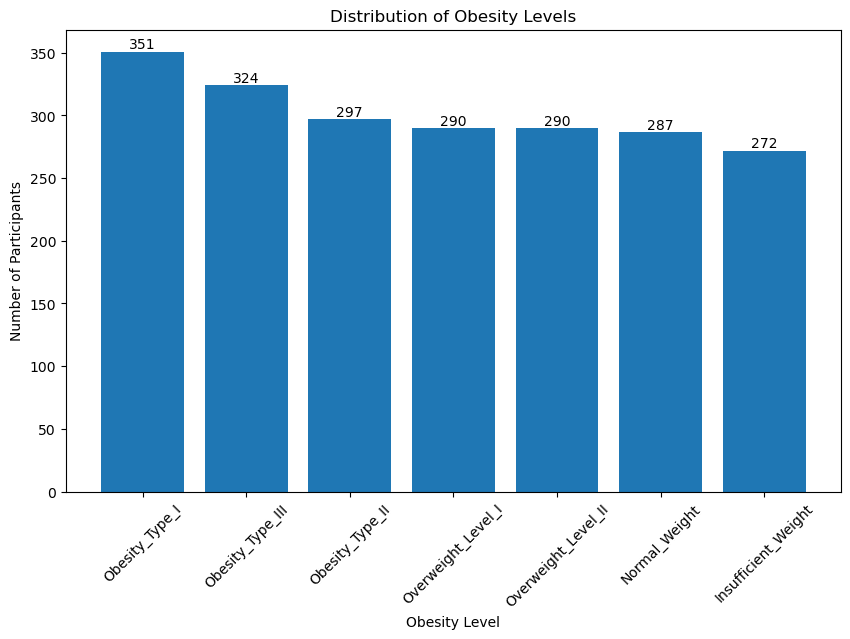

In [11]:
counts = obesity['NObeyesdad'].value_counts()

plt.figure(figsize=(10,6))
bars = plt.bar(counts.index, counts.values)

plt.title("Distribution of Obesity Levels")
plt.xlabel("Obesity Level")
plt.ylabel("Number of Participants")

plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

3.4.4 Distribution Analysis

Purpose: The purpose of this section is to examine the distribution of numerical variables in the dataset. Understanding the distribution helps identify data characteristics such as central tendency, spread, skewness, kurtosis, and potential outliers before building machine learning models.

3.4.4.1 Age Distribution

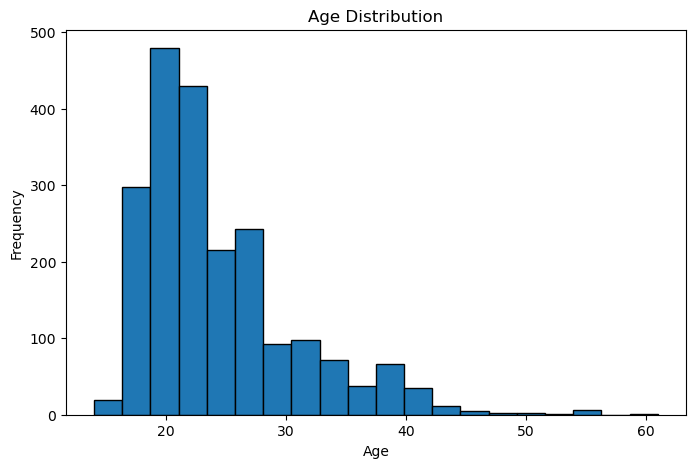

In [12]:
plt.figure(figsize=(8,5))

plt.hist(obesity['Age'], bins=20, edgecolor='black')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Summary Statistic

In [13]:
print(obesity["Age"].describe())
print()
print("Skewness :", round(obesity["Age"].skew(),2))
print()
print("Kurtosis :", round(obesity["Age"].kurt(),2))


count    2111.000000
mean       24.312600
std         6.345968
min        14.000000
25%        19.947192
50%        22.777890
75%        26.000000
max        61.000000
Name: Age, dtype: float64

Skewness : 1.53

Kurtosis : 2.83


3.4.4.2 Height Distribution

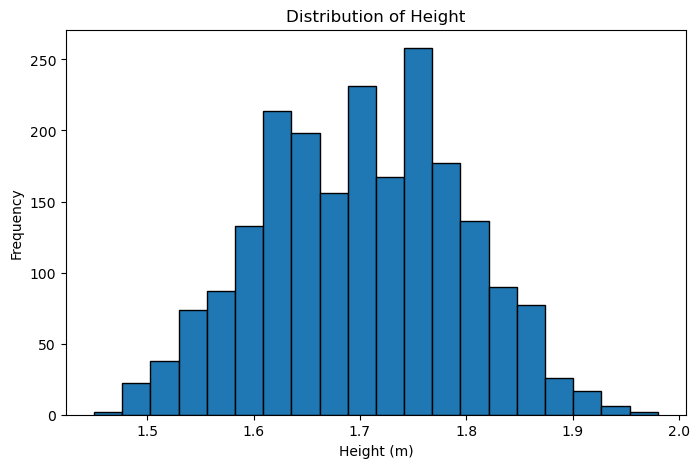

In [14]:
plt.figure(figsize=(8,5))

plt.hist(obesity["Height"],
         bins=20,
         edgecolor="black")

plt.title("Distribution of Height")
plt.xlabel("Height (m)")
plt.ylabel("Frequency")

plt.show()

Summary Statistic

In [15]:
print(obesity["Height"].describe())
print()
print("Skewness :", round(obesity["Height"].skew(),2))
print()
print("Kurtosis :", round(obesity["Height"].kurt(),2))

count    2111.000000
mean        1.701677
std         0.093305
min         1.450000
25%         1.630000
50%         1.700499
75%         1.768464
max         1.980000
Name: Height, dtype: float64

Skewness : -0.01

Kurtosis : -0.56


3.4.4.3 Weight Distribution

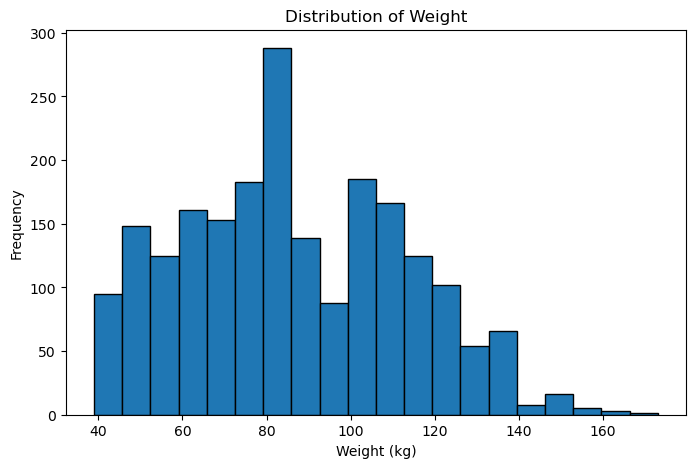

In [16]:
plt.figure(figsize=(8,5))

plt.hist(obesity["Weight"],
         bins=20,
         edgecolor="black")

plt.title("Distribution of Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

plt.show()

In [17]:
print(obesity["Weight"].describe())
print()
print("Skewness :", round(obesity["Weight"].skew(),2))
print()
print("Kurtosis :", round(obesity["Weight"].kurt(),2))

count    2111.000000
mean       86.586058
std        26.191172
min        39.000000
25%        65.473343
50%        83.000000
75%       107.430682
max       173.000000
Name: Weight, dtype: float64

Skewness : 0.26

Kurtosis : -0.7


3.4.4.4 BMI Distribution

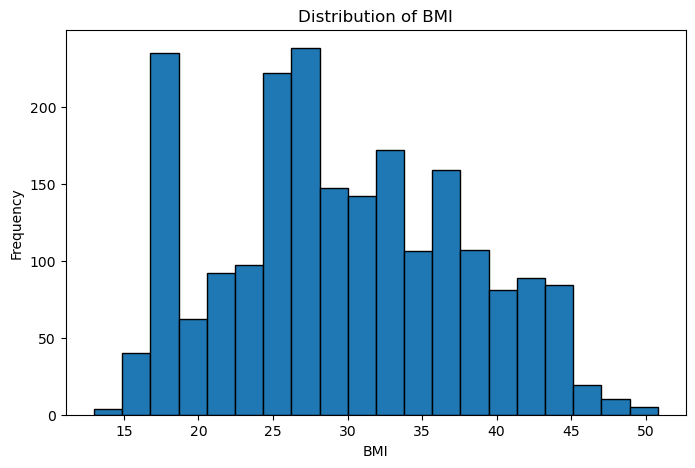

In [18]:
plt.figure(figsize=(8,5))

plt.hist(obesity["BMI"],
         bins=20,
         edgecolor="black")

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

Summary Statistic

In [19]:
print(obesity["BMI"].describe())
print()
print("Skewness :", round(obesity["BMI"].skew(),2))
print()
print("Kurtosis :", round(obesity["BMI"].kurt(),2))

count    2111.000000
mean       29.700159
std         8.011337
min        12.998685
25%        24.325802
50%        28.719089
75%        36.016501
max        50.811753
Name: BMI, dtype: float64

Skewness : 0.15

Kurtosis : -0.81


3.4.4.5 Physical Activity (FAF) Distribution

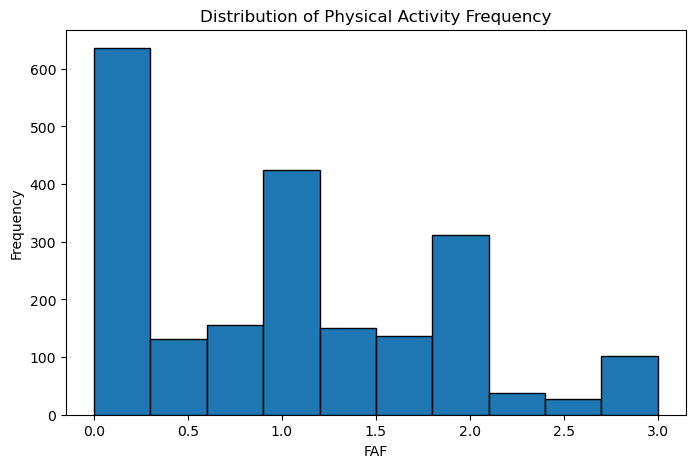

In [20]:
plt.figure(figsize=(8,5))

plt.hist(obesity["FAF"],
         bins=10,
         edgecolor="black")

plt.title("Distribution of Physical Activity Frequency")
plt.xlabel("FAF")
plt.ylabel("Frequency")

plt.show()

Summary Statistic

In [21]:
print(obesity["FAF"].describe())
print()
print("Skewness :", round(obesity["FAF"].skew(),2))
print()
print("Kurtosis :", round(obesity["FAF"].kurt(),2))

count    2111.000000
mean        1.010298
std         0.850592
min         0.000000
25%         0.124505
50%         1.000000
75%         1.666678
max         3.000000
Name: FAF, dtype: float64

Skewness : 0.5

Kurtosis : -0.62


3.4.4.6 Water Intake (CH20) Distribution

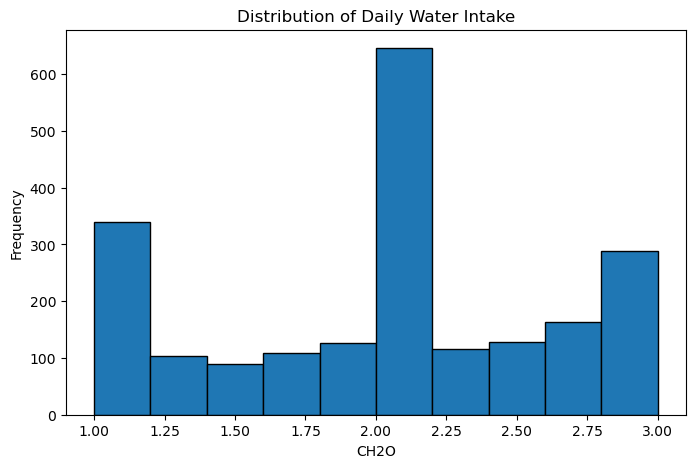

In [22]:
plt.figure(figsize=(8,5))

plt.hist(obesity["CH2O"],
         bins=10,
         edgecolor="black")

plt.title("Distribution of Daily Water Intake")
plt.xlabel("CH2O")
plt.ylabel("Frequency")

plt.show()

Summary Statistic

In [23]:
print(obesity["CH2O"].describe())
print()
print("Skewness :", round(obesity["CH2O"].skew(),2))
print()
print("Kurtosis :", round(obesity["CH2O"].kurt(),2))

count    2111.000000
mean        2.008011
std         0.612953
min         1.000000
25%         1.584812
50%         2.000000
75%         2.477420
max         3.000000
Name: CH2O, dtype: float64

Skewness : -0.1

Kurtosis : -0.88


3.4.4.7 Distribution Summary Table

In [24]:
summary = pd.DataFrame({
    "Mean": obesity[["Age","Height","Weight","BMI","FAF","CH2O"]].mean(),
    "Median": obesity[["Age","Height","Weight","BMI","FAF","CH2O"]].median(),
    "Std": obesity[["Age","Height","Weight","BMI","FAF","CH2O"]].std(),
    "Skewness": obesity[["Age","Height","Weight","BMI","FAF","CH2O"]].skew(),
    "Kurtosis": obesity[["Age","Height","Weight","BMI","FAF","CH2O"]].kurt()
})

summary = summary.round(2)

summary

,Mean,Median,Std,Skewness,Kurtosis
Age,24.31,22.78,6.35,1.53,2.83
Height,1.70,1.70,0.09,-0.01,-0.56
Weight,86.59,83.00,26.19,0.26,-0.70
BMI,29.70,28.72,8.01,0.15,-0.81
FAF,1.01,1.00,0.85,0.50,-0.62
CH2O,2.01,2.00,0.61,-0.10,-0.88


3.4.4.8 Overall Distribution Summary

    Taken together, the distribution analysis of the six numerical variables reveals several important patterns that inform the subsequent data preparation stage. Both Age and Weight exhibit positive (right) skewness, with skewness values of 1.53 and 0.26, respectively. This indicates that a smaller number of older or heavier individuals extend the upper tails of these distributions. In contrast, Height and CH20 are nearly symmetrical, with skewness values close to zero (-0.01 and -0.10, respectively), while BMI shows only a mild positive skewness of 0.15. FAF displays moderate positive skewness (0.50), reflecting the uneven distribution of self-reported physical activity frequency among participants.

	In terms of kurtosis, most variables, namely Height, Weight, BMI , FAF, and CH20 are platykurtic, with kurtosis values below zero. This indicates flatter distributions and a wider spread of values compared with a normal distribution, which is consistent with the multiple distinct peaks observed in their respective histograms. Age is the only variable that is leptokurtic, with a kurtosis value of 2.83, indicating a more peaked distribution with a greater concentration of values around the early twenties.

	 Overall, these findings confirm that the numerical variables differ considerably in terms of scale, spread, and distributional shape. Since algorithms such as K-Nearest Neighbours are sensitive to the magnitude of input features, variables with larger scales could otherwise have a greater influence on the learning process. Therefore,feature scaling using StandardScaler(), as carried out later in Section 4.6, is justified to standardise all numerical variables onto a common scale before model training.


3.4.5 Correlation Analysis

In [25]:
corr = obesity.corr(numeric_only=True)

corr["Weight"].sort_values(ascending=False)

Weight    1.000000
BMI       0.934806
Height    0.463136
FCVC      0.216125
Age       0.202560
CH2O      0.200575
NCP       0.107469
FAF      -0.051436
TUE      -0.071561
Name: Weight, dtype: float64

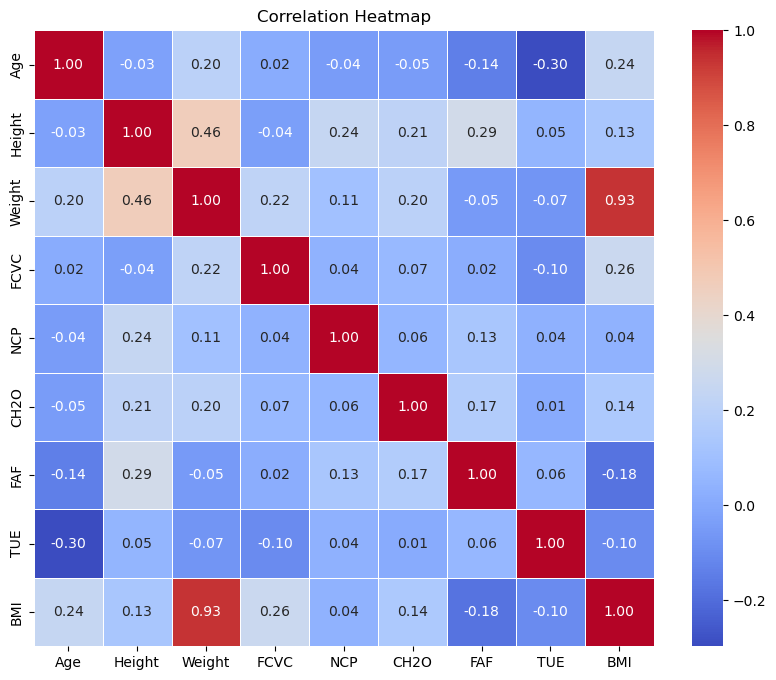

In [26]:
plt.figure(figsize=(10,8))

correlation = obesity.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

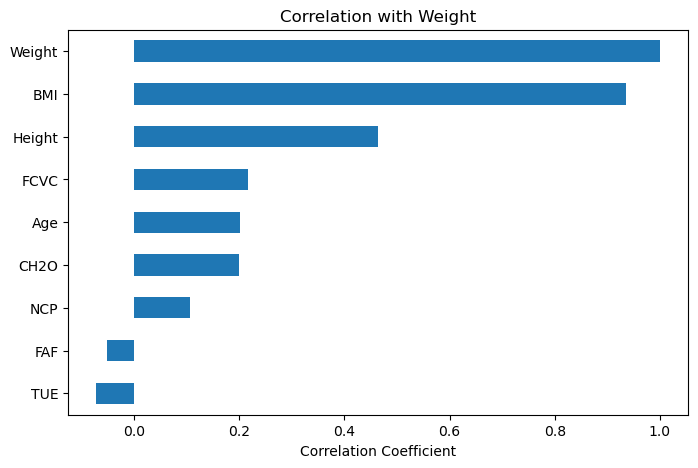

In [27]:
corr = obesity.corr(numeric_only=True)

corr_weight = corr["Weight"].sort_values()

plt.figure(figsize=(8,5))

corr_weight.plot(kind="barh")

plt.title("Correlation with Weight")

plt.xlabel("Correlation Coefficient")

plt.show()

Report:

1. Height shows a moderate positive correlation with Weight (r = 0.463), indicating that taller individuals generally tend to have higher body weight. However, the correlation is not strong, suggesting that other lifestyle factors also influence body weight.

2. FCVC has a weak positive correlation with Weight (r = 0.216), suggesting only a slight linear relationship. Further analysis is required to determine whether vegetable consumption has a meaningful effect on body weight.

3. Age shows a moderate negative correlation with TUE (r = -0.30), the strongest negative relationship observed in the heatmap, suggesting that younger individuals tend to spend more time using technology devices, while this behaviour gradually declines with age.

4. FAF shows a weak negative correlation with BMI (r = -0.18), indicating that individuals with higher physical activity frequency tend to have slightly lower BMI values, which aligns with general expectations that regular physical activity contributes to lower body weight, although the relationship is not strong on its own.

5. Overall, most numerical variables show weak-to-moderate correlations with one another, with Weight and BMI standing out as the only pair exhibiting a very strong relationship (r = 0.93). This suggests that multicollinearity among the numerical features is limited, and most variables can be retained as independent predictors during model training without significant redundancy concerns.

Conclusion:

Based on the correlation analysis, Height has the strongest positive relationship with Weight among the numerical variables. Lifestyle-related variables such as vegetable consumption (FCVC), water intake (CH2O), and age exhibit only weak positive correlations, while physical activity (FAF) and technology usage (TUE) show very weak negative correlations. This suggests that body weight is likely influenced by multiple interacting factors rather than any single numerical variable.

3.4.6 Initial Business Insight

The initial analysis suggests that obesity is influenced by a combination of factors rather than a single variable. Factors such as physical characteristics, lifestyle behaviors, eating habits and family history all appear to play a role in obesity levels. These findings indicate that obesity is a complex health issue that cannot be explained by one factor alone.

Based on these observations, developing a machine learning model is a suitable approach for predicting obesity levels, as it can analyse multiple factors simultaneously. The model may help healthcare professionals identify individuals who are at higher risk of obesity , allowing earlier intervention and supporting better healthcare decision-making. The influence of these variables will be examined further in the exploratory data analysis and modelling stages.



4.0 Data Preparation
- check missing values
- data cleaning - Rounding / Standardising Numeric Precision
- check duplicate records
- remove duplicate records
- detect outliers
- data transformation
- data standardisation

4.1 Missing Values

Missing value detection was performed to identify incomplete records in the dataset before data preprocessing. Missing values can reduce data quality and negatively affect the performance of machine learning models. Therefore, each attribute was examined using the isnull().sum() function in Pandas.

The results showed that there were no missing values in any of the dataset attributes. As a result, no imputation or missing value treatment was required, and the dataset was considered complete for further preprocessing and analysis.

In [28]:
# Check missing values
missing = obesity.isnull().sum()

# Calculate percentage of missing values
missing_percent = obesity.isnull().mean() * 100

# Create summary table
missing_obesity = pd.DataFrame({
    "Missing Value": missing,
    "Percentage (%)": missing_percent
})

missing_obesity

,Missing Value,Percentage (%)
Gender,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
family_history_with_overweight,0,0.0
FAVC,0,0.0
FCVC,0,0.0
NCP,0,0.0
CAEC,0,0.0
SMOKE,0,0.0


4.2 Standardising Numeric Precision

The numerical variables were rounded to a consistent number of decimal places using the round() function in Pandas. This step was carried out to improve the consistency and readability of the dataset by removing unnecessary decimal values. Since the extra decimal precision does not provide additional value for the machine learning models, rounding the values makes the dataset easier to interpret while preserving the original information. 


In [29]:
obesity['Age'] = obesity['Age'].round(0).astype(int)         
obesity['Height'] = obesity['Height'].round(2)             
obesity['Weight'] = obesity['Weight'].round(2)                

for col in ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']:
    obesity[col] = obesity[col].round(0).astype(int)   

In [30]:
# Display data after rounding
print("Dataset after rounding:")
obesity[['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']].head(10)
obesity

Dataset after rounding:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Female,21,1.62,64.00,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21,1.52,56.00,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23,1.80,77.00,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27,1.80,87.00,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22,1.78,89.80,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,21,1.71,131.41,yes,yes,3,3,Sometimes,no,2,no,2,1,Sometimes,Public_Transportation,Obesity_Type_III,44.901475
2107,Female,22,1.75,133.74,yes,yes,3,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III,43.741923
2108,Female,23,1.75,133.69,yes,yes,3,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III,43.543817
2109,Female,24,1.74,133.35,yes,yes,3,3,Sometimes,no,3,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III,44.071535


4.3 Duplicate Records

Duplicate record detection was performed to identify repeated observations in the dataset before model development. Duplicate records may reduce data quality and influence the performance of machine learning models by giving the same information multiple times, which can introduce bias and affect the reliability of the model. 

The pandas function obesity.duplicate().sum() was used to count the number of duplicate records in the dataset, while the duplicate percentage was calculated using the formula : (number of duplicate records / total number of records) * 100%.


In [31]:
# Check duplicate rows
duplicate = obesity.duplicated().sum()

print("Duplicate Rows:", duplicate)
print("Percentage:", duplicate / len(obesity) * 100)

Duplicate Rows: 27
Percentage: 1.27901468498342


In [32]:
# Remove duplicate rows
obesity = obesity.drop_duplicates().copy()

# Verify duplicate removal
duplicate = obesity.duplicated().sum()

print("Duplicate Rows:", duplicate)
print("Percentage:", duplicate / len(obesity) * 100)

Duplicate Rows: 0
Percentage: 0.0


In [33]:
print(obesity.shape)
#print(obesity.duplicated().sum())

(2084, 18)


4.4 Outlier Detection
   
Outliers are extreme values that differ significantly from the rest of the data. Detecting outliers is important because they may affect the performance of machine learning models. In this project, boxplots were used to identify potential outliers in the numerical features.

Boxplots and the Interquartile Range (IQR) method were used to detect potential outliers in the numerical attributes. Although several outliers were identified, they were retained because they represent valid observations related to obesity levels rather than data entry errors. Removing these values could reduce the dataset's ability to represent real-world obesity conditions.

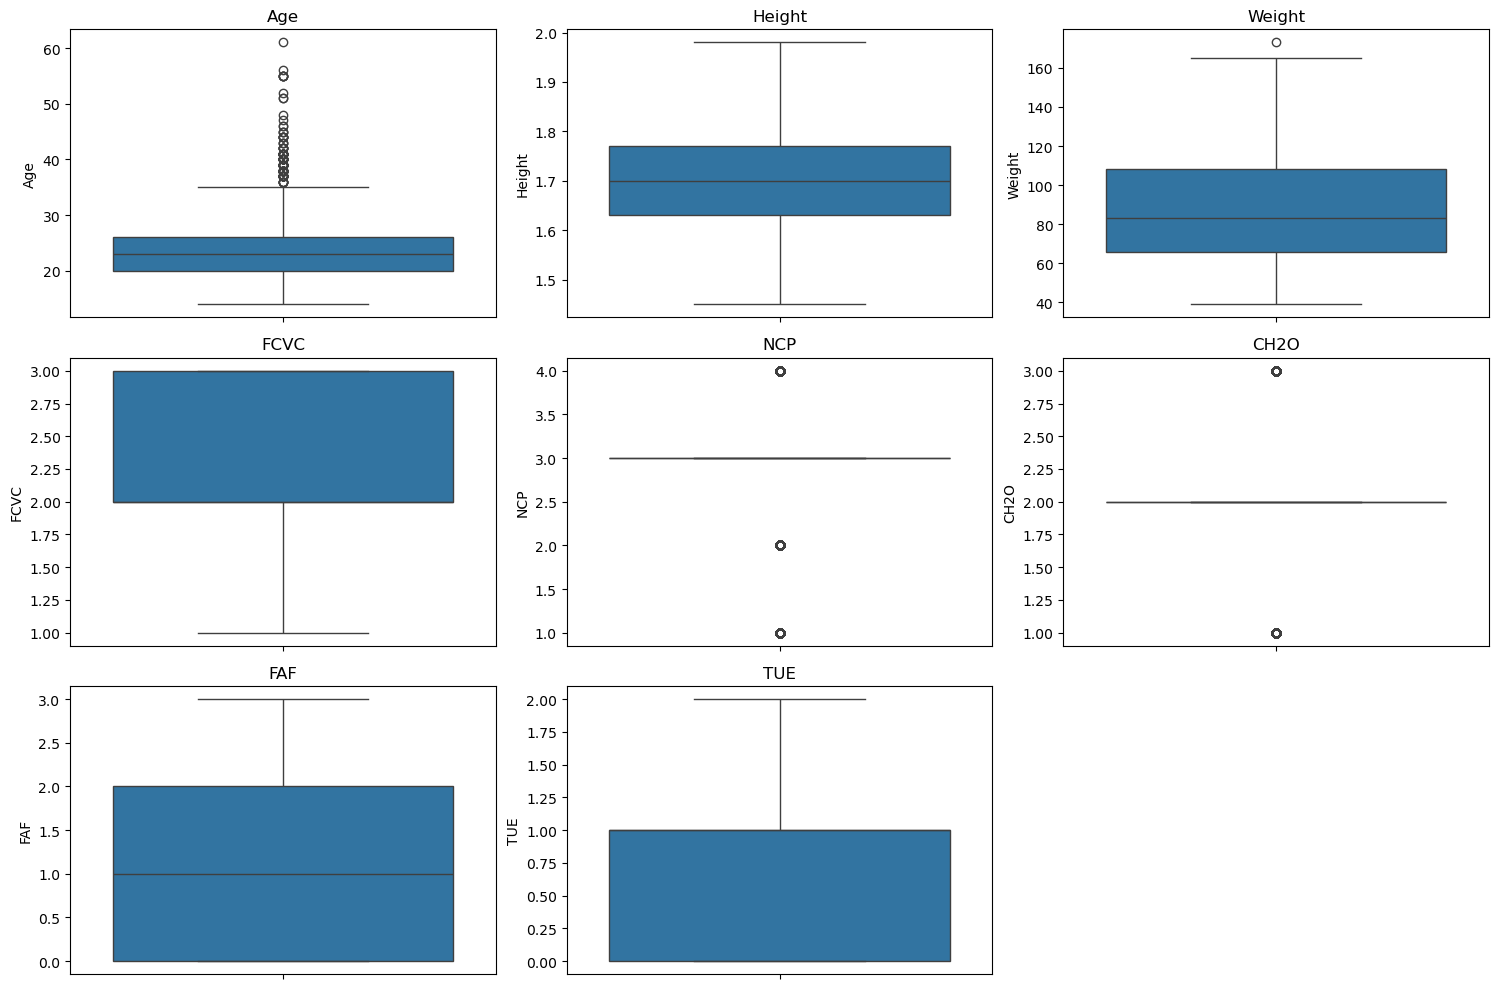

In [34]:
numerical_columns = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE"
]

plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=obesity[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [35]:
print("Outlier Detection using IQR:\n")

for col in numerical_columns:
    Q1 = obesity[col].quantile(0.25)
    Q3 = obesity[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = obesity[(obesity[col] < lower) | (obesity[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Outlier Detection using IQR:

Age: 160 outliers
Height: 0 outliers
Weight: 1 outliers
FCVC: 0 outliers
NCP: 621 outliers
CH2O: 980 outliers
FAF: 0 outliers
TUE: 0 outliers


4.5 Data Transformation
   
Data transformation is performed to convert the dataset into a suitable format for machine learning algorithms. Since machine learning models require numerical input, categorical variables must be transformed into numerical values. In this project, Label Encoding was applied to all categorical attributes to ensure that the dataset is compatible with subsequent modelling processes.

Step 1: Identify categorical variables

In [36]:
categorical_columns = obesity.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')


Step 2: Apply label encoding3

In [37]:
# Keep an untouched copy of the original human-readable dataset
obesity_clean = obesity.copy()

# Create a separate dataset for modelling
obesity_model = obesity_clean.copy()

# Store a separate encoder for each categorical variable
encoders = {}

for column in categorical_columns:
    encoders[column] = LabelEncoder()
    obesity_model[column] = encoders[column].fit_transform(
        obesity_model[column]
    )

# The target variable gets its own encoder
target_encoder = encoders["NObeyesdad"]

# Use the encoded dataframe for modelling
obesity = obesity_model.copy()

print("Categorical variables encoded successfully.")
print("\nNObeyesdad encoding:")
for code, category in enumerate(target_encoder.classes_):
    print(f"{code}: {category}")

Categorical variables encoded successfully.

NObeyesdad encoding:
0: Insufficient_Weight
1: Normal_Weight
2: Obesity_Type_I
3: Obesity_Type_II
4: Obesity_Type_III
5: Overweight_Level_I
6: Overweight_Level_II


In [38]:
obesity.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,0,21,1.62,64.0,1,0,2,3,2,0,2,0,0,1,3,3,1,24.386526
1,0,21,1.52,56.0,1,0,3,3,2,1,3,1,3,0,2,3,1,24.238227
2,1,23,1.80,77.0,1,0,2,3,2,0,2,0,2,1,1,3,1,23.765432
3,1,27,1.80,87.0,0,0,3,3,2,0,2,0,2,0,1,4,5,26.851852
4,1,22,1.78,89.8,0,0,2,1,2,0,2,0,0,0,2,3,6,28.342381


In [39]:
print(obesity.dtypes)

Gender                              int64
Age                                 int64
Height                            float64
Weight                            float64
family_history_with_overweight      int64
FAVC                                int64
FCVC                                int64
NCP                                 int64
CAEC                                int64
SMOKE                               int64
CH2O                                int64
SCC                                 int64
FAF                                 int64
TUE                                 int64
CALC                                int64
MTRANS                              int64
NObeyesdad                          int64
BMI                               float64
dtype: object


4.6 Data Standardisation (Feature Scaling)

Feature scaling was performed to standardise the numerical variables so that they are on a similar scale before model training. Standardisation helps prevent features with larger numerical ranges from dominating those with smaller ranges and can improve the performance of many machine learning algorithms, such as K-Nearest Neighbours (KNN), Support Vector Machine (SVM), and Logistic Regression.

In this project, the StandardScaler technique was used to transform the numerical attributes to have a mean of approximately 0 and a standard deviation of approximately 1.

In [40]:
# Create StandardScaler object
scaler = StandardScaler()

# Select only continuous numerical features
scale_columns = [
    "Age",
    "Height",
    "Weight",
    "BMI",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE"
]

# Apply feature scaling
obesity[scale_columns] = scaler.fit_transform(obesity[scale_columns])

print("Feature scaling completed successfully.")


Feature scaling completed successfully.


In [41]:
obesity.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,0,-0.526361,-0.885896,-0.873773,1,0,-0.729935,0.372487,2,0,-0.016796,0,-1.122977,0.491540,3,3,1,-0.671335
1,0,-0.526361,-1.957839,-1.179235,1,0,0.981183,0.372487,2,1,1.441672,1,2.215516,-0.993054,2,3,1,-0.689817
2,1,-0.212906,1.043601,-0.377396,1,0,-0.729935,0.372487,2,0,-0.016796,0,1.102685,0.491540,1,3,1,-0.748741
3,1,0.414004,1.043601,0.004432,0,0,0.981183,0.372487,2,0,-0.016796,0,1.102685,-0.993054,1,4,5,-0.364088
4,1,-0.369633,0.829213,0.111344,0,0,-0.729935,-2.135630,2,0,-0.016796,0,-1.122977,-0.993054,2,3,6,-0.178326


4.7 Restoring Data for Visualisation

In [42]:
# Use the untouched human-readable dataset for EDA and visualisation
obesity_visual = obesity_clean.copy()

# Remove duplicate rows for visualisation only
before_count = len(obesity_visual)

obesity_visual = obesity_visual.drop_duplicates().reset_index(drop=True)

after_count = len(obesity_visual)

print("Human-readable dataset prepared for visualisation.")
print(f"Duplicates removed: {before_count - after_count}")
print(f"Final rows: {after_count}")

Human-readable dataset prepared for visualisation.
Duplicates removed: 0
Final rows: 2084


In [43]:
obesity_visual[["Gender","Age", "Weight", "BMI"]].head()

,Gender,Age,Weight,BMI
0,Female,21,64.0,24.386526
1,Female,21,56.0,24.238227
2,Male,23,77.0,23.765432
3,Male,27,87.0,26.851852
4,Male,22,89.8,28.342381


5.0 Exploratory Data Analysis (20 EDA)

In [44]:
eda_folder = Path("eda_graphs")
eda_folder.mkdir(exist_ok=True)

chart_number = 1

def save_eda_chart():
    global chart_number
    filename = eda_folder / f"chart_{chart_number:02d}.png"
    plt.gcf().savefig(filename, dpi=150, bbox_inches="tight")
    print(f"Updated: {filename}")
    chart_number += 1

In [45]:
import squarify

obesity_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
    "Overweight_Level_I",
    "Overweight_Level_II",
]

obesity_plot = obesity_visual.copy() if "obesity_visual" in locals() else obesity.copy()

if obesity_plot["NObeyesdad"].dtype in ["int64", "float64"]:
    obesity_plot["NObeyesdad"] = obesity_plot["NObeyesdad"].map(target_mapping)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

5.1 Body Characteristic and Target Variable

5.1.1 Height vs Weight 

Updated: eda_graphs/chart_01.png


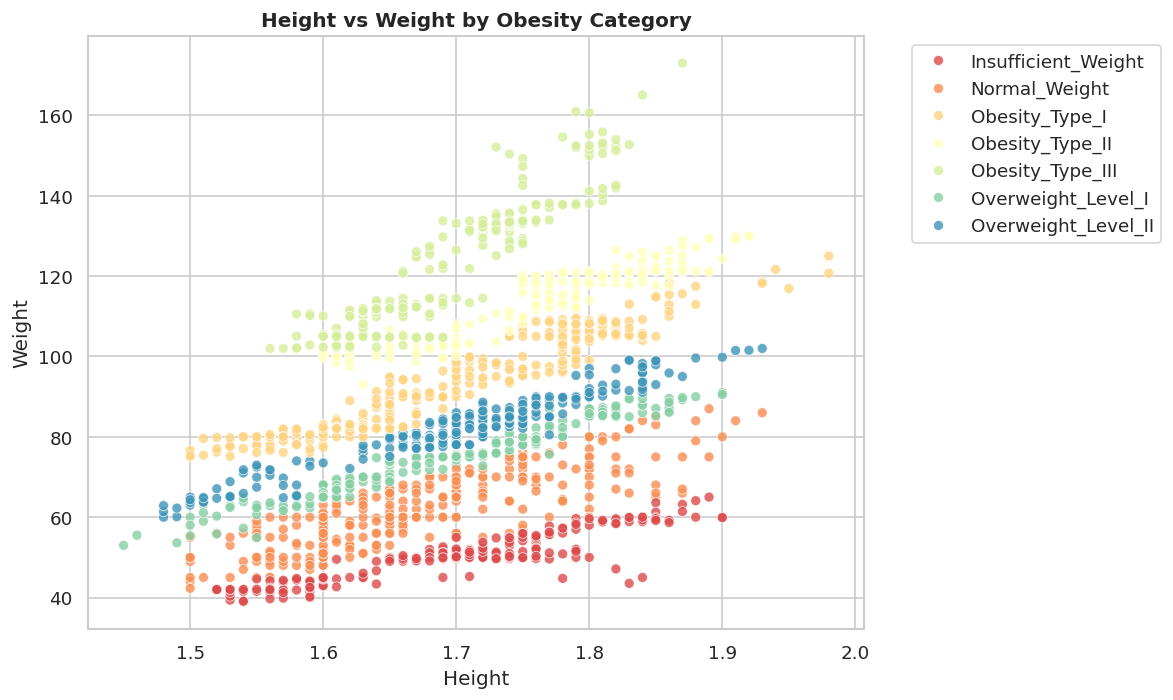

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=obesity_plot,
    x="Height",
    y="Weight",
    hue="NObeyesdad",
    hue_order=obesity_order,
    palette="Spectral",
    alpha=0.8,
)
plt.title(
    "Height vs Weight by Obesity Category", fontsize=12, fontweight="bold"
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
save_eda_chart()
plt.show()

5.1.2 Age Distribution across Obesity Levels

Updated: eda_graphs/chart_02.png


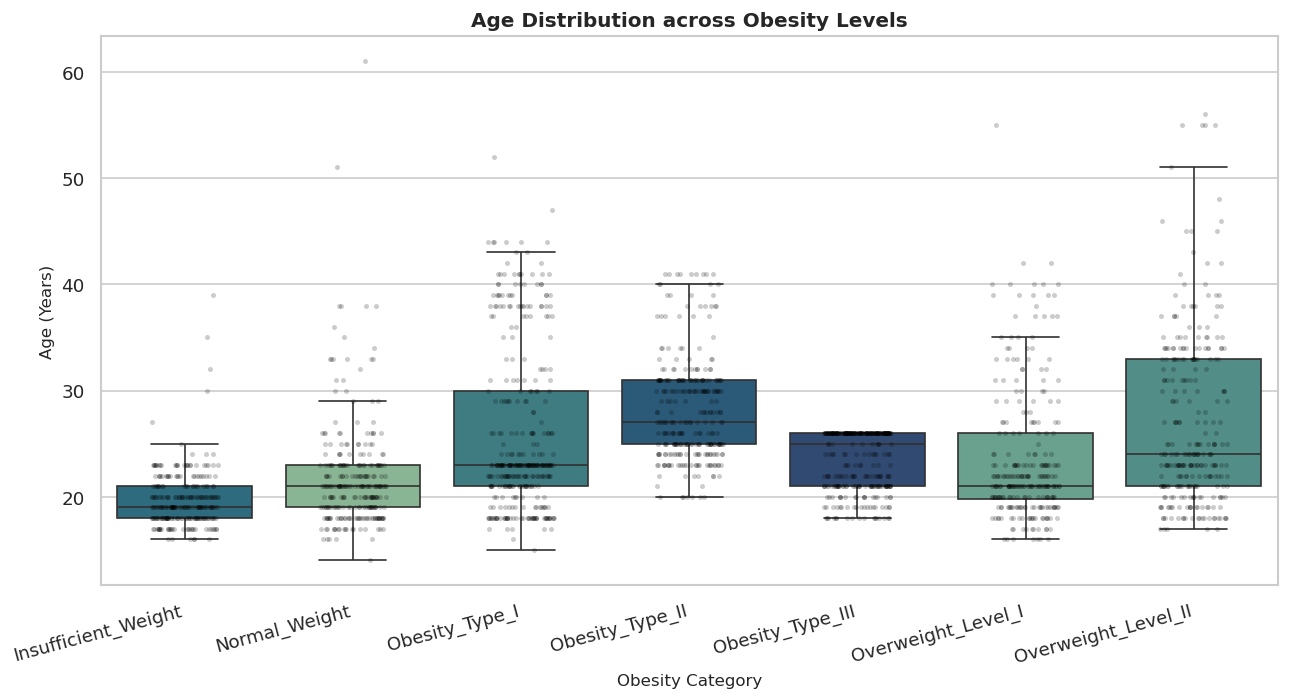

In [47]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=obesity_plot,
    x="NObeyesdad",
    y="Age",
    hue="NObeyesdad",  
    order=obesity_order,
    palette="crest",
    fliersize=0,
    legend=False,
)

sns.stripplot(
    data=obesity_plot,
    x="NObeyesdad",
    y="Age",
    order=obesity_order,
    color="black",
    alpha=0.2,
    jitter=0.2,
    size=3,
)

plt.title(
    "Age Distribution across Obesity Levels", fontsize=12, fontweight="bold"
)
plt.xlabel("Obesity Category", fontsize=10)
plt.ylabel("Age (Years)", fontsize=10)

plt.xticks(rotation=15, ha="right")

plt.tight_layout()
save_eda_chart()
plt.show()

5.1.3 Gender Proportion within Each Obesity Level (100% Stacked Bar)

Updated: eda_graphs/chart_03.png


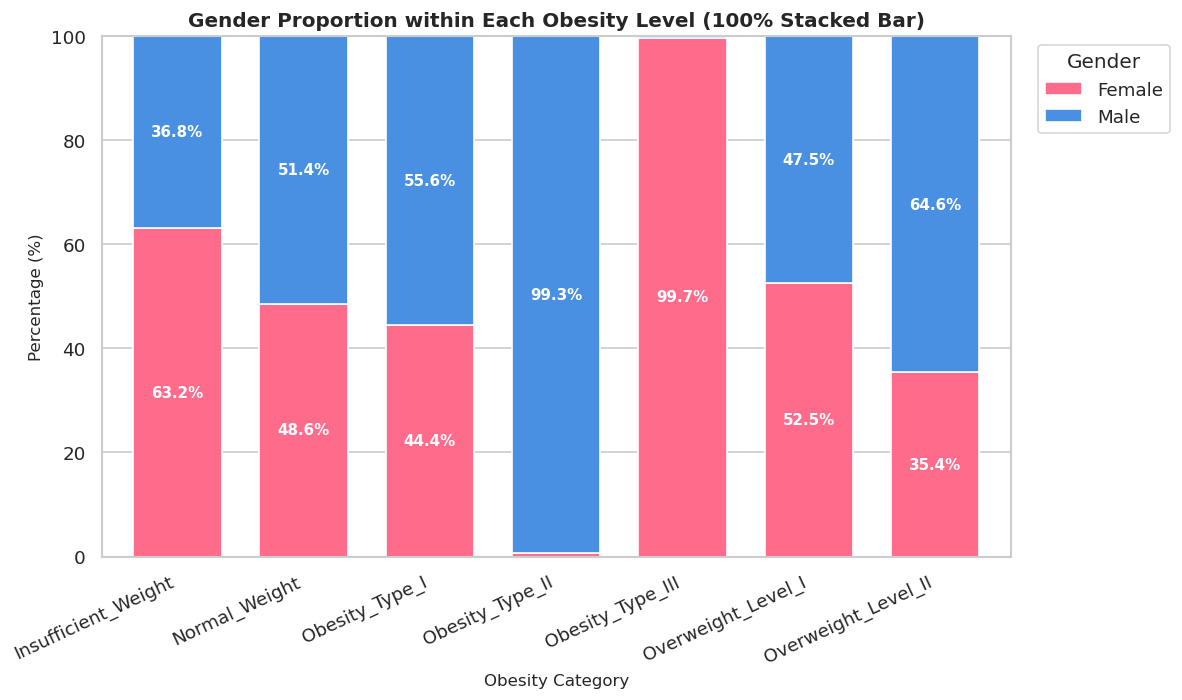

In [48]:
ct_gender = pd.crosstab(
    obesity_plot["NObeyesdad"], obesity_plot["Gender"]
).reindex(obesity_order)
ct_gender = ct_gender[["Female", "Male"]].apply(
    lambda r: r / r.sum() * 100, axis=1
)

custom_colors = ["#FF6B8B", "#4A90E2"]

ax = ct_gender.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=custom_colors,  
    edgecolor="white",
    width=0.7,
)

plt.title(
    "Gender Proportion within Each Obesity Level (100% Stacked Bar)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Obesity Category", fontsize=10)
plt.ylabel("Percentage (%)", fontsize=10)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Gender", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.ylim(0, 100)

for p in ax.patches:
    height = p.get_height()
    width = p.get_width()
    x, y = p.get_xy()
    if height > 5: 
        ax.annotate(
            f"{height:.1f}%",
            (x + width / 2, y + height / 2),
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=9,
        )

plt.tight_layout()
save_eda_chart()
plt.show()

5.1.4 Impact of Family History on BMI Density Distribution

Updated: eda_graphs/chart_04.png


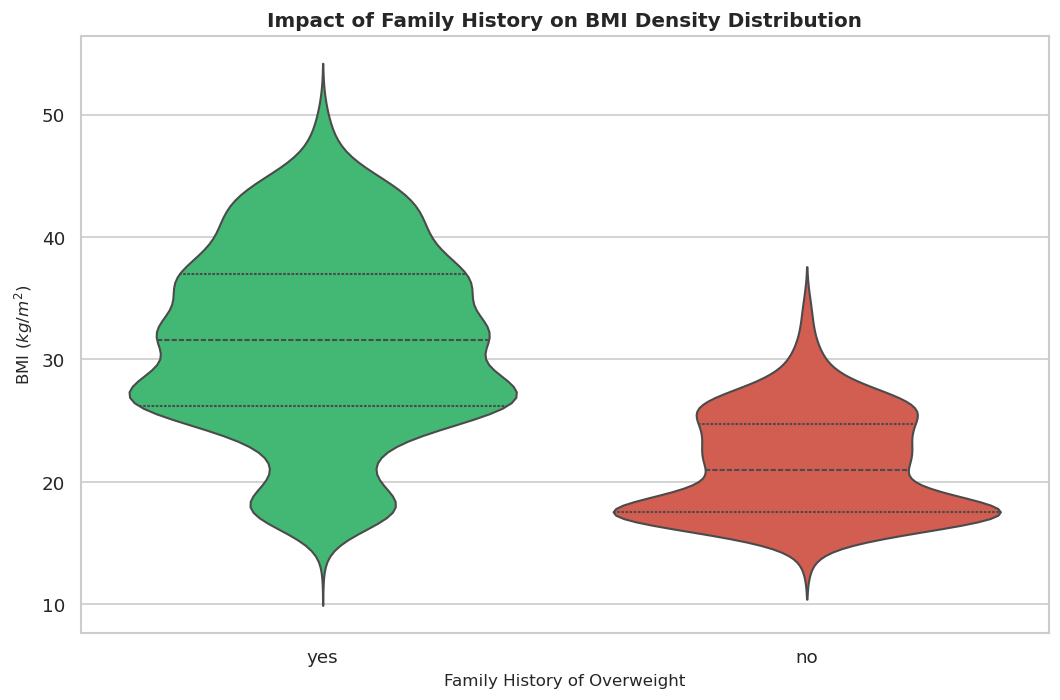

In [49]:
plt.figure(figsize=(9, 6))

sns.violinplot(
    data=obesity_plot,
    x="family_history_with_overweight",
    y="BMI",
    hue="family_history_with_overweight", 
    palette=["#2ECC71", "#E74C3C"],  
    inner="quartile",  
    legend=False,
)

plt.title(
    "Impact of Family History on BMI Density Distribution",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Family History of Overweight", fontsize=10)
plt.ylabel("BMI ($kg/m^2$)", fontsize=10)

plt.tight_layout()
save_eda_chart()
plt.show()

5.2 Dietary Habits and Weight Management

5.2.1 Vegetable Consumption Frequency (FCVC) across Obesity Levels

Updated: eda_graphs/chart_05.png


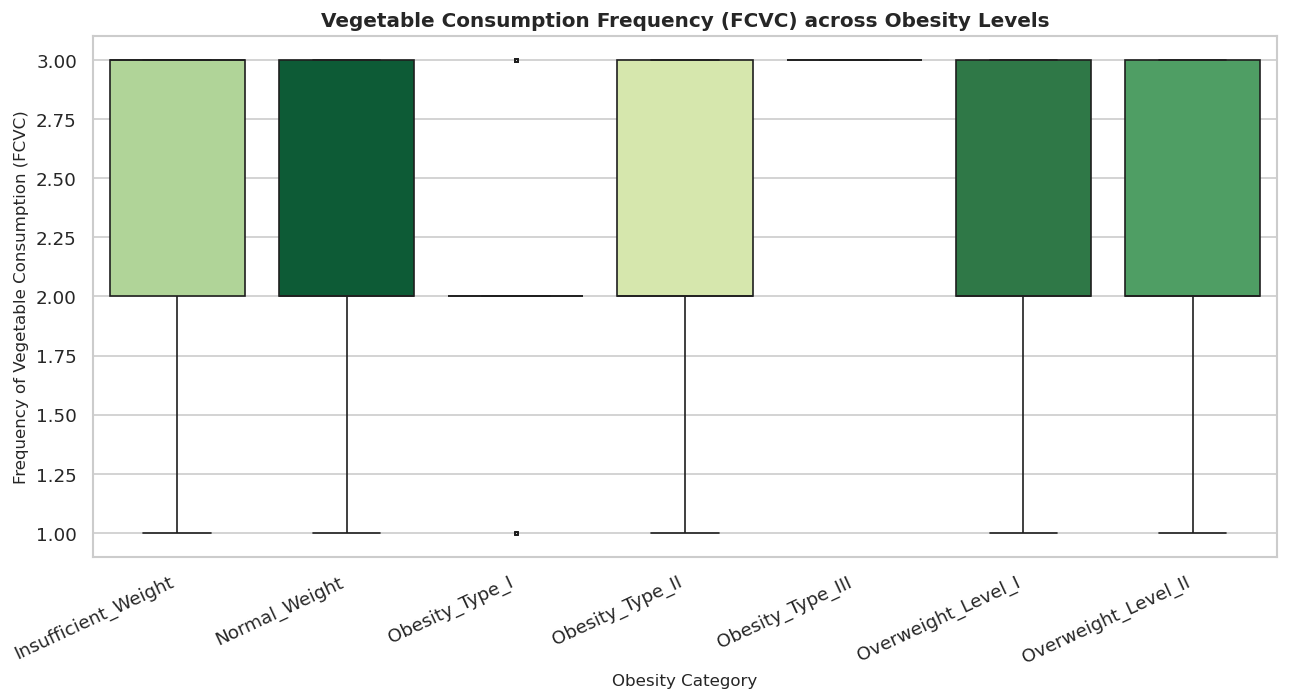

In [50]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=obesity_plot,
    x="NObeyesdad",
    y="FCVC",
    hue="NObeyesdad", 
    order=obesity_order,
    palette="YlGn_r",  
    fliersize=2,
    legend=False,
)

plt.title(
    "Vegetable Consumption Frequency (FCVC) across Obesity Levels",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Obesity Category", fontsize=10)
plt.ylabel("Frequency of Vegetable Consumption (FCVC)", fontsize=10)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
save_eda_chart()
plt.show()

5.2.2 Interaction Effect: Main Meals (NCP) & High-Calorie Food (FAVC) on BMI

Updated: eda_graphs/chart_06.png


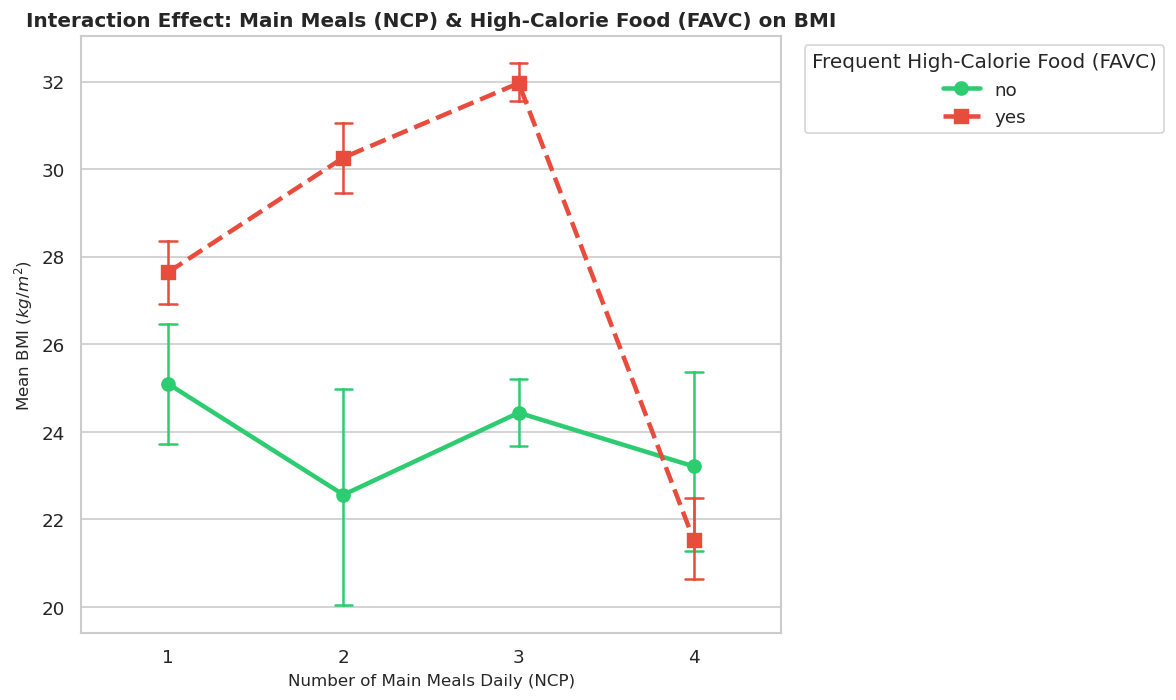

In [51]:
plt.figure(figsize=(10, 6))

sns.pointplot(
    data=obesity_plot,
    x="NCP",
    y="BMI",
    hue="FAVC",
    palette=["#2ECC71", "#E74C3C"],  
    markers=["o", "s"],
    linestyles=["-", "--"],
    capsize=0.1, 
    err_kws={"linewidth": 1.5},
)

plt.title(
    "Interaction Effect: Main Meals (NCP) & High-Calorie Food (FAVC) on BMI",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Number of Main Meals Daily (NCP)", fontsize=10)
plt.ylabel("Mean BMI ($kg/m^2$)", fontsize=10)
plt.legend(
    title="Frequent High-Calorie Food (FAVC)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
save_eda_chart()
plt.show()

5.2.3 Crosstab Heatmap: Snack Consumption (CAEC) vs Obesity Levels

Updated: eda_graphs/chart_07.png


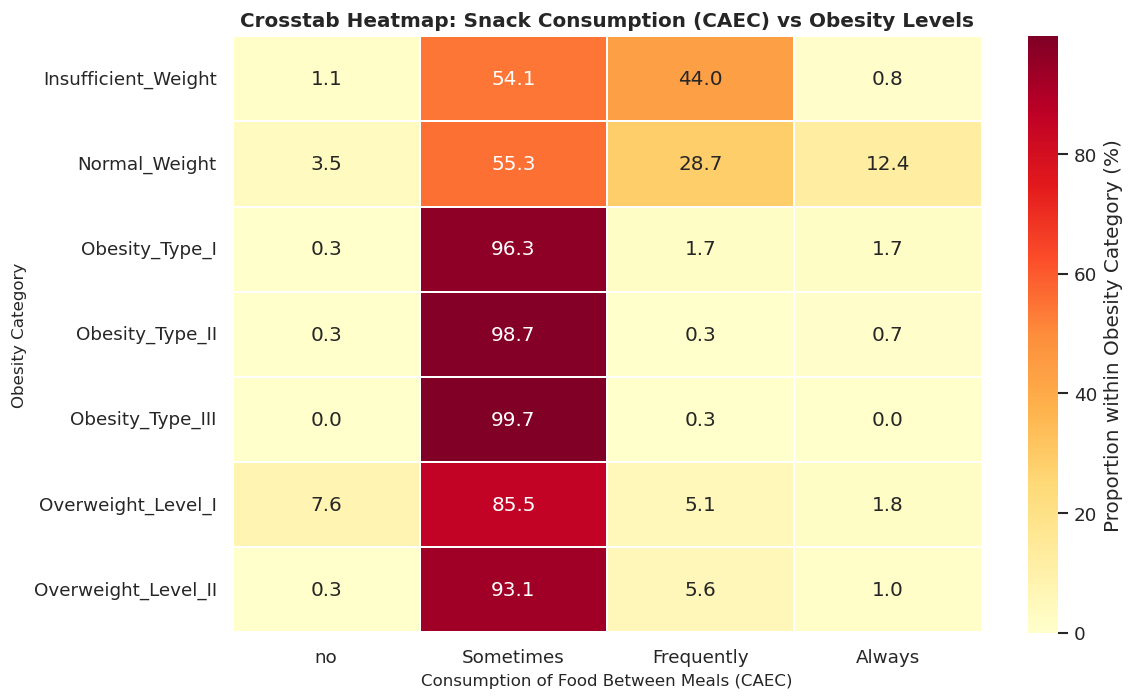

In [52]:
caec_order = ["no", "Sometimes", "Frequently", "Always"]

ct_caec = pd.crosstab(
    obesity_plot["NObeyesdad"],
    obesity_plot["CAEC"],
    normalize="index",  
) * 100

ct_caec = ct_caec.reindex(index=obesity_order, columns=caec_order).fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(
    ct_caec,
    annot=True,  
    fmt=".1f", 
    cmap="YlOrRd",  
    cbar_kws={"label": "Proportion within Obesity Category (%)"},
    linewidths=1,
)

plt.title(
    "Crosstab Heatmap: Snack Consumption (CAEC) vs Obesity Levels",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Consumption of Food Between Meals (CAEC)", fontsize=10)
plt.ylabel("Obesity Category", fontsize=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
save_eda_chart()
plt.show()

5.2.4 Daily Water Consumption (CH2O) Density Distribution Across Key Categories

Updated: eda_graphs/chart_08.png


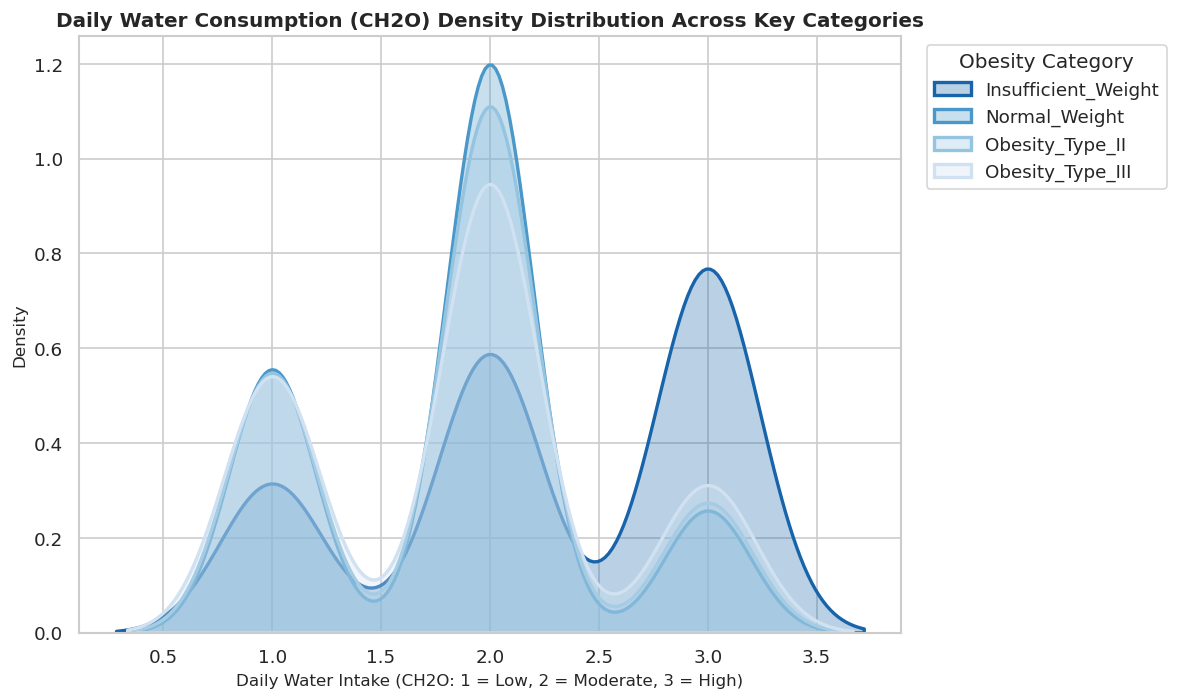

In [53]:
target_categories = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Obesity_Type_II",
    "Obesity_Type_III",
]
obesity_kde = obesity_plot[
    obesity_plot["NObeyesdad"].isin(target_categories)
].copy()

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=obesity_kde,
    x="CH2O",
    hue="NObeyesdad",
    hue_order=target_categories,
    palette="Blues",  
    fill=True,
    common_norm=False,  
    alpha=0.3,
    linewidth=2,
)

plt.title(
    "Daily Water Consumption (CH2O) Density Distribution Across Key Categories",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Daily Water Intake (CH2O: 1 = Low, 2 = Moderate, 3 = High)", fontsize=10)
plt.ylabel("Density", fontsize=10)
plt.legend(
    title="Obesity Category",
    labels=target_categories,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
save_eda_chart()
plt.show()

5.2.5 Alcohol Consumption Frequency (CALC) vs Mean BMI (with 95% CI)

Updated: eda_graphs/chart_09.png


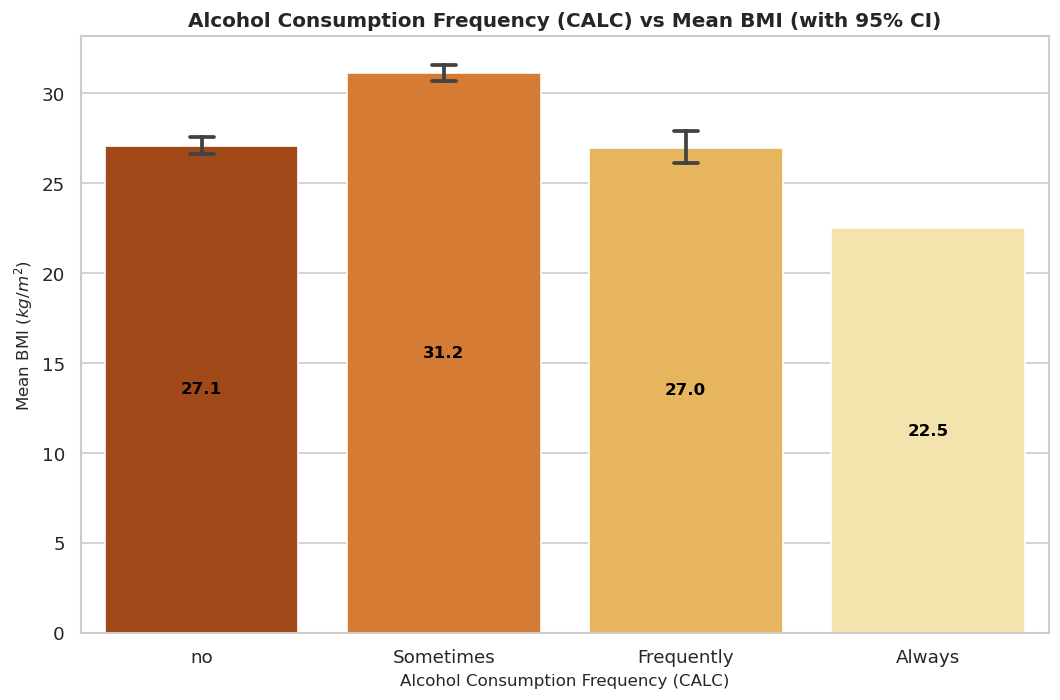

In [54]:
calc_order = ["no", "Sometimes", "Frequently", "Always"]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=obesity_plot,
    x="CALC",
    y="BMI",
    hue="CALC", 
    order=calc_order,
    palette="YlOrBr_r",
    errorbar=("ci", 95), 
    capsize=0.1, 
    legend=False,
)

plt.title(
    "Alcohol Consumption Frequency (CALC) vs Mean BMI (with 95% CI)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Alcohol Consumption Frequency (CALC)", fontsize=10)
plt.ylabel("Mean BMI ($kg/m^2$)", fontsize=10)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f"{height:.1f}",
            (p.get_x() + p.get_width() / 2.0, height / 2),
            ha="center",
            va="center",
            color="black",
            fontweight="bold",
            fontsize=10,
        )

plt.tight_layout()
save_eda_chart()
plt.show()

5.3 Lifestyle and Physical Activity

5.3.1 Multifaceted Impact: Physical Activity (FAF) vs Tech Use (TUE) on BMI by Gender

Updated: eda_graphs/chart_10.png


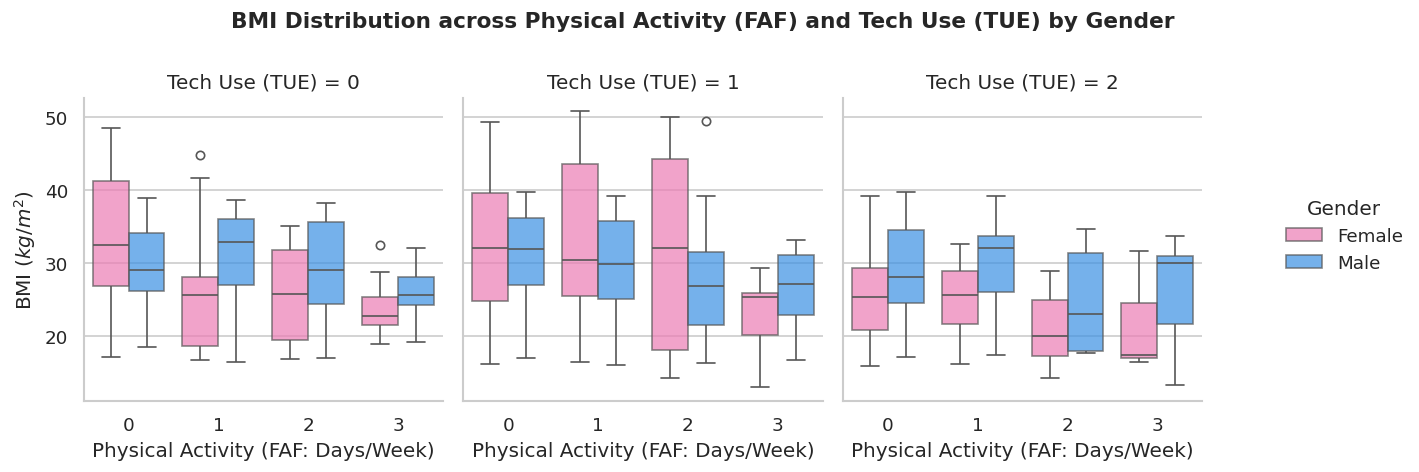

In [55]:
g = sns.catplot(
    data=obesity_plot,
    x="FAF",
    y="BMI",
    hue="Gender",
    col="TUE", 
    kind="box",
    palette={"Female": "#FF69B4", "Male": "#1E90FF"},
    height=4,
    aspect=0.9,
    boxprops={"alpha": 0.7},
)

g.fig.subplots_adjust(top=0.8, right=0.85)
g.fig.suptitle(
    "BMI Distribution across Physical Activity (FAF) and Tech Use (TUE) by Gender",
    fontsize=13,
    fontweight="bold",
)
g.set_axis_labels("Physical Activity (FAF: Days/Week)", "BMI ($kg/m^2$)")
g.set_titles("Tech Use (TUE) = {col_name}")

save_eda_chart()
plt.show()

5.3.2 Physical Activity (FAF) vs BMI across Family History of Overweight

Updated: eda_graphs/chart_11.png


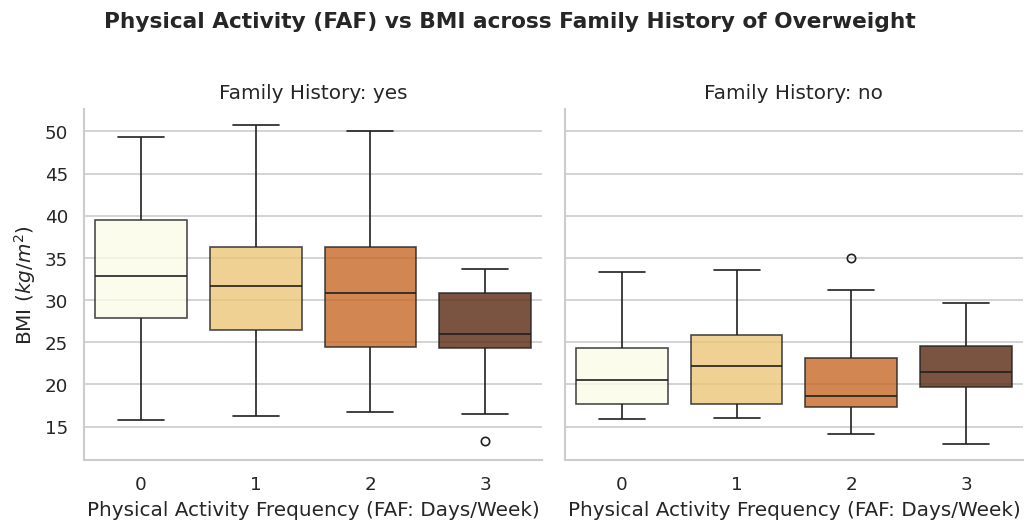

In [56]:
g = sns.catplot(
    data=obesity_plot,
    x="FAF",
    y="BMI",
    hue="FAF",
    col="family_history_with_overweight", 
    kind="box",
    palette="YlOrBr",  
    height=4.5,
    aspect=0.95,
    boxprops={"alpha": 0.8},
    legend=False,
)

g.fig.subplots_adjust(top=0.8, right=1.0)

g.fig.suptitle(
    "Physical Activity (FAF) vs BMI across Family History of Overweight",
    fontsize=13,
    fontweight="bold",
)
g.set_axis_labels("Physical Activity Frequency (FAF: Days/Week)", "BMI ($kg/m^2$)")
g.set_titles("Family History: {col_name}")

save_eda_chart()
plt.show()

5.3.3 Average Physical Activity Frequency (FAF) by Transportation Method (MTRANS)

Updated: eda_graphs/chart_12.png


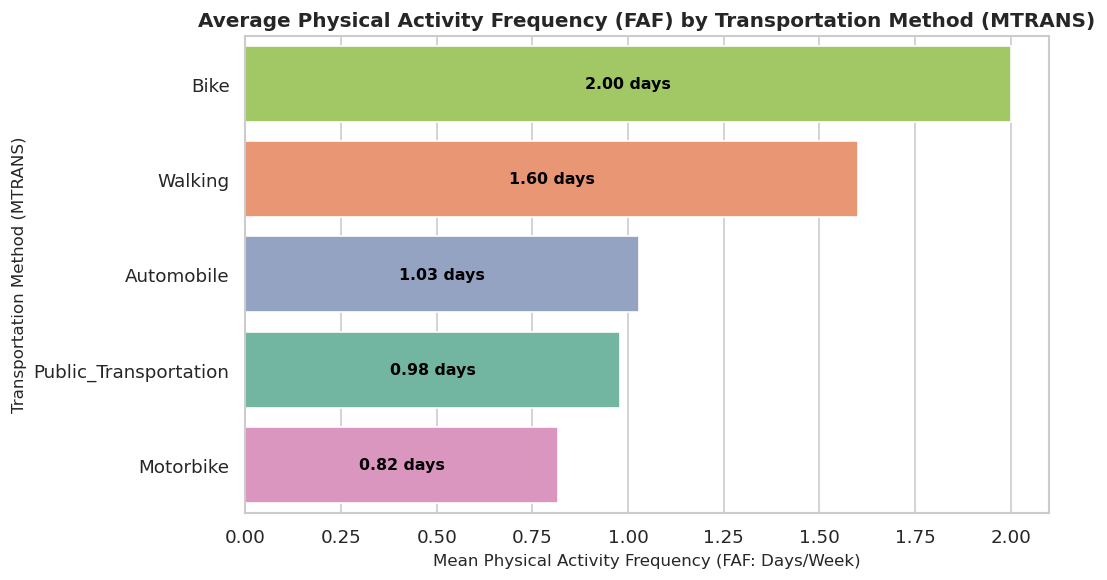

In [57]:
mtrans_order = (
    obesity_plot.groupby("MTRANS")["FAF"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=obesity_plot,
    x="FAF",
    y="MTRANS",
    hue="MTRANS",
    order=mtrans_order,
    palette="Set2", 
    errorbar=None,
    capsize=0.15,
    legend=False,
)

plt.title(
    "Average Physical Activity Frequency (FAF) by Transportation Method (MTRANS)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Mean Physical Activity Frequency (FAF: Days/Week)", fontsize=10)
plt.ylabel("Transportation Method (MTRANS)", fontsize=10)

for p in ax.patches:
    width = p.get_width()
    if not np.isnan(width) and width > 0:
        ax.annotate(
            f"{width:.2f} days",
            (width / 2.0, p.get_y() + p.get_height() / 2.0),
            ha="center",
            va="center",
            color="black",
            fontweight="bold",
            fontsize=9.5,
        )

plt.tight_layout()
save_eda_chart()
plt.show()

5.3.4 Combined Impact of Calorie Monitoring (SCC) & Smoking (SMOKE) on BMI

Updated: eda_graphs/chart_13.png


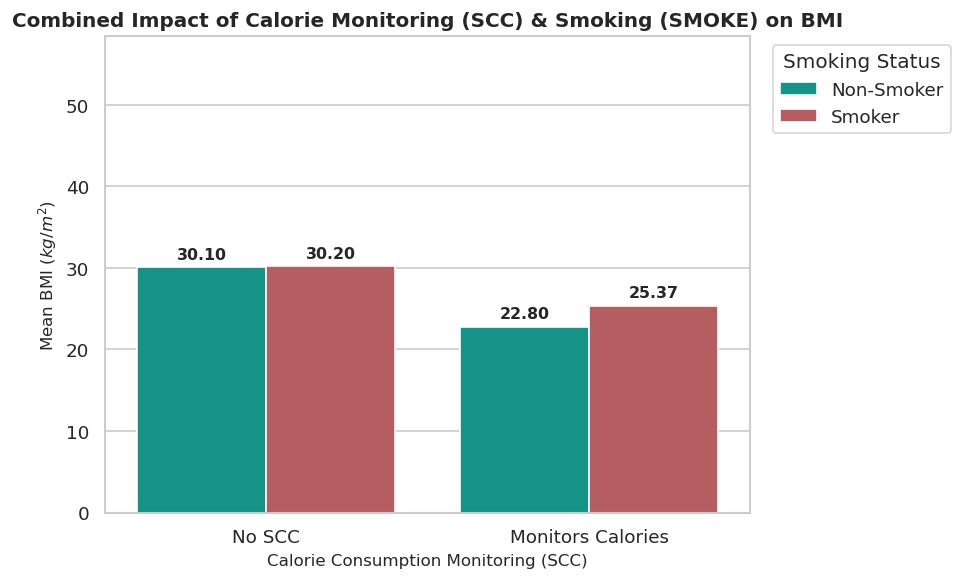

In [58]:
scc_map = {0: "No SCC", 1: "Monitors Calories (SCC)", "no": "No SCC", "yes": "Monitors Calories"}
smoke_map = {0: "Non-Smoker", 1: "Smoker", "no": "Non-Smoker", "yes": "Smoker"}

if "SCC" in obesity_plot.columns:
    obesity_plot["SCC_label"] = obesity_plot["SCC"].replace(scc_map)
if "SMOKE" in obesity_plot.columns:
    obesity_plot["SMOKE_label"] = obesity_plot["SMOKE"].replace(smoke_map)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=obesity_plot,
    x="SCC_label",
    y="BMI",
    hue="SMOKE_label",
    palette={"Non-Smoker": "#00A896", "Smoker": "#C44E52"},  
    errorbar=None,  
    capsize=0.1,
)

plt.title(
    "Combined Impact of Calorie Monitoring (SCC) & Smoking (SMOKE) on BMI",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Calorie Consumption Monitoring (SCC)", fontsize=10)
plt.ylabel("Mean BMI ($kg/m^2$)", fontsize=10)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
            fontweight="bold",
            fontsize=9.5,
        )

plt.legend(title="Smoking Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.ylim(0, obesity_plot["BMI"].max() * 1.15) 

plt.tight_layout()
save_eda_chart()
plt.show()

5.3.5 Transportation Method Disparities between Extreme Weight Groups

Updated: eda_graphs/chart_14.png


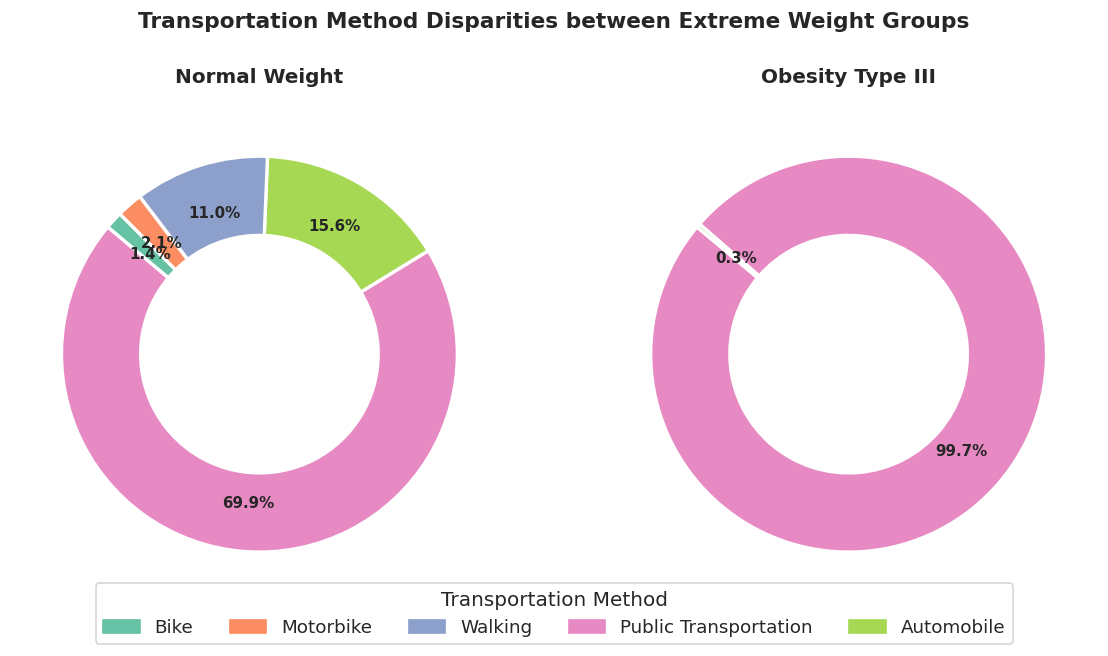

In [59]:
normal_data = obesity_plot[obesity_plot["NObeyesdad"].astype(str).str.contains("Normal", case=False, na=False)]
obesity_data = obesity_plot[obesity_plot["NObeyesdad"].astype(str).str.contains("Type_III|Type III", case=False, na=False)]

normal_counts = normal_data["MTRANS"].value_counts()
obesity_counts = obesity_data["MTRANS"].value_counts()

all_categories = list(set(normal_counts.index).union(set(obesity_counts.index)))
colors = sns.color_palette("Set2", len(all_categories))
color_map = dict(zip(all_categories, colors))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

wedges1, texts1, autotexts1 = axes[0].pie(
    normal_counts,
    labels=None,
    autopct="%1.1f%%",
    pctdistance=0.75,
    colors=[color_map[cat] for cat in normal_counts.index],
    startangle=140,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
)
axes[0].set_title("Normal Weight", fontsize=12, fontweight="bold", pad=15)

wedges2, texts2, autotexts2 = axes[1].pie(
    obesity_counts,
    labels=None,
    autopct="%1.1f%%",
    pctdistance=0.75,
    colors=[color_map[cat] for cat in obesity_counts.index],
    startangle=140,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
)
axes[1].set_title("Obesity Type III", fontsize=12, fontweight="bold", pad=15)

for autotext in autotexts1 + autotexts2:
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")

legend_labels = [cat.replace("_", " ") for cat in all_categories]
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[cat]) for cat in all_categories]

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    title="Transportation Method",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=min(len(all_categories), 5),
    frameon=True,
)

fig.suptitle(
    "Transportation Method Disparities between Extreme Weight Groups",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
save_eda_chart()
plt.show()

5.4 Advanced Risk Profiling

5.4.1 Dual Effect of Gender & Alcohol Consumption (CALC) on BMI

Updated: eda_graphs/chart_15.png


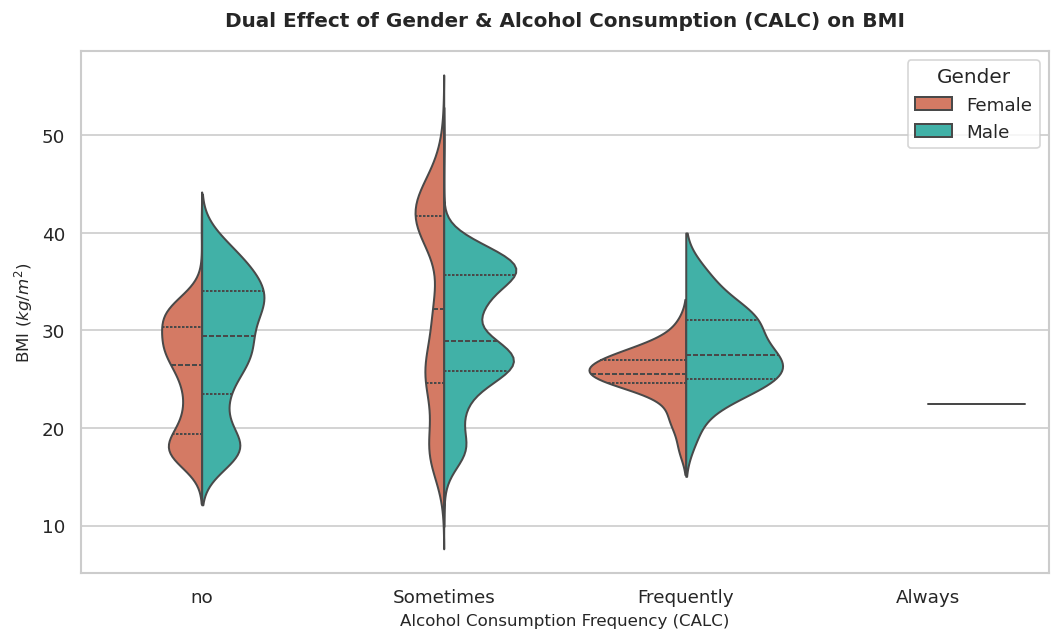

In [60]:
plt.figure(figsize=(9, 5.5))

calc_order = ["no", "Sometimes", "Frequently", "Always"]

existing_order = [c for c in calc_order if c in obesity_plot["CALC"].unique()]

sns.violinplot(
    data=obesity_plot,
    x="CALC",
    y="BMI",
    hue="Gender",
    order=existing_order,
    palette={"Female": "#E76F51", "Male": "#2EC4B6"},
    split=True, 
    inner="quartile",  
    linewidth=1.2,
)

plt.title(
    "Dual Effect of Gender & Alcohol Consumption (CALC) on BMI",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Alcohol Consumption Frequency (CALC)", fontsize=10)
plt.ylabel("BMI ($kg/m^2$)", fontsize=10)
plt.legend(title="Gender", loc="upper right", frameon=True)

plt.tight_layout()
save_eda_chart()
plt.show()

5.4.2 Obesity Tier Composition by Smoking Status (SMOKE)

Updated: eda_graphs/chart_16.png


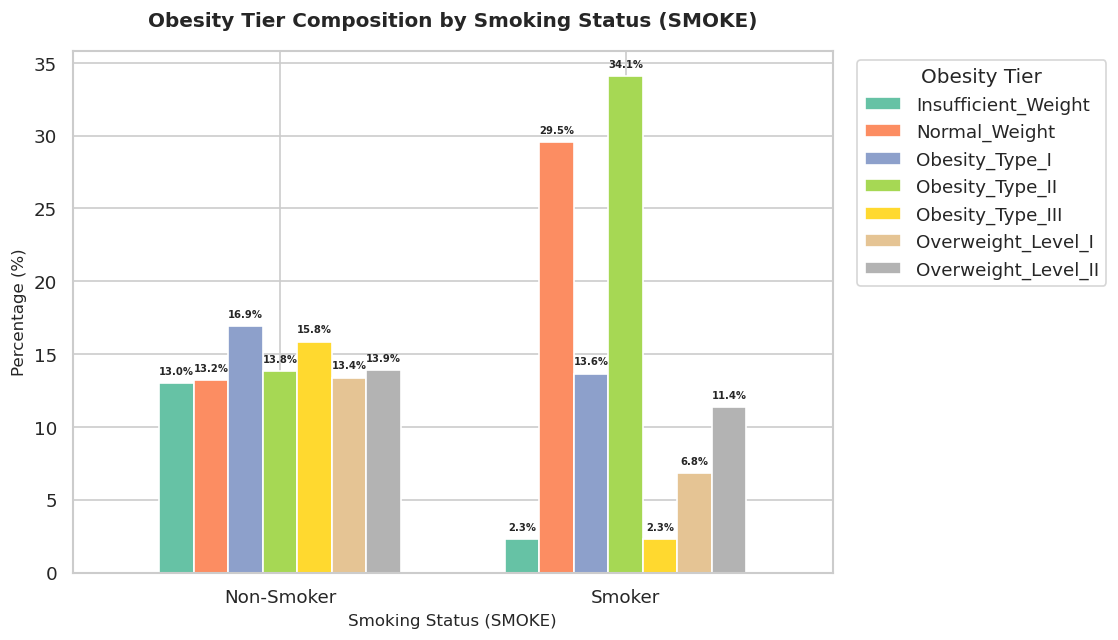

In [61]:
smoke_cross = (
    pd.crosstab(
        obesity_plot["SMOKE"], obesity_plot["NObeyesdad"], normalize="index"
    )
    * 100
)

ax = smoke_cross.plot(
    kind="bar", figsize=(9.5, 5.5), colormap="Set2", width=0.7, edgecolor="white"
)

plt.title(
    "Obesity Tier Composition by Smoking Status (SMOKE)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Smoking Status (SMOKE)", fontsize=10)
plt.ylabel("Percentage (%)", fontsize=10)
plt.xticks(ticks=[0, 1], labels=["Non-Smoker", "Smoker"], rotation=0)

for p in ax.patches:
    height = p.get_height()
    if height > 1.5:  
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height + 0.5),
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold",
        )

plt.legend(
    title="Obesity Tier",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)
plt.tight_layout()
save_eda_chart()
plt.show()

5.4.3 Interaction Effect: Family History & High-Caloric Food (FAVC) on BMI

Updated: eda_graphs/chart_17.png


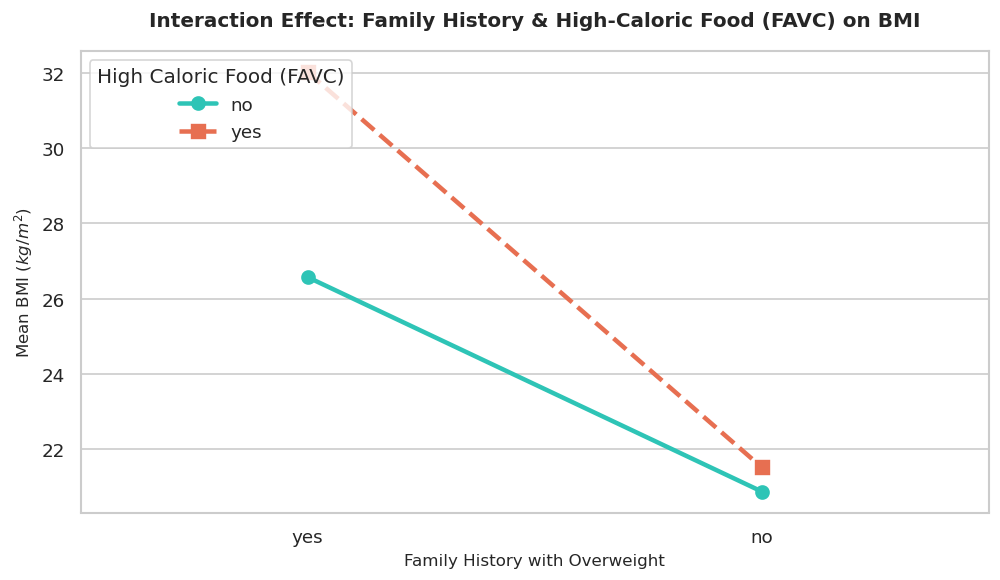

In [62]:
plt.figure(figsize=(8.5, 5))

sns.pointplot(
    data=obesity_plot,
    x="family_history_with_overweight",
    y="BMI",
    hue="FAVC",
    palette={"yes": "#E76F51", "no": "#2EC4B6"},
    markers=["o", "s"],
    linestyles=["-", "--"],
    capsize=0.1,
    errorbar=None,
)

plt.title(
    "Interaction Effect: Family History & High-Caloric Food (FAVC) on BMI",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Family History with Overweight", fontsize=10)
plt.ylabel("Mean BMI ($kg/m^2$)", fontsize=10)
plt.legend(title="High Caloric Food (FAVC)", loc="upper left", frameon=True)

plt.tight_layout()
save_eda_chart()
plt.show()

5.4.4 Cumulative Risk Factor Score vs. Average BMI

Updated: eda_graphs/chart_18.png


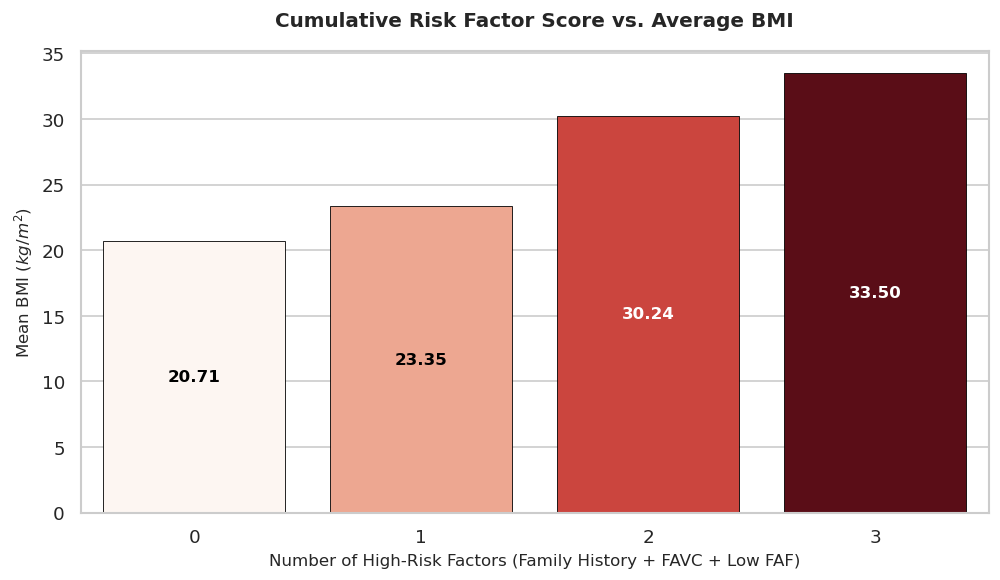

In [63]:
risk_df = obesity_plot.copy()
risk_df["Risk_Score"] = (
    (risk_df["family_history_with_overweight"] == "yes").astype(int)
    + (risk_df["FAVC"] == "yes").astype(int)
    + (risk_df["FAF"] < 1.0).astype(int) 
)

plt.figure(figsize=(8.5, 5))

ax = sns.barplot(
    data=risk_df,
    x="Risk_Score",
    y="BMI",
    hue="Risk_Score",  
    palette="Reds",
    legend=False,  
    errorbar=None,
    edgecolor="black",
    linewidth=0.5,
)

plt.title(
    "Cumulative Risk Factor Score vs. Average BMI",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel(
    "Number of High-Risk Factors (Family History + FAVC + Low FAF)",
    fontsize=10,
)
plt.ylabel("Mean BMI ($kg/m^2$)", fontsize=10)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}",
        (p.get_x() + p.get_width() / 2.0, height / 2.0),
        ha="center",
        va="center",
        color="white" if height > 28 else "black",
        fontweight="bold",
        fontsize=10,
    )

plt.tight_layout()
save_eda_chart()
plt.show()

5.4.5 Detailed BMI Distribution Across Transportation Modes (MTRANS)

Updated: eda_graphs/chart_19.png


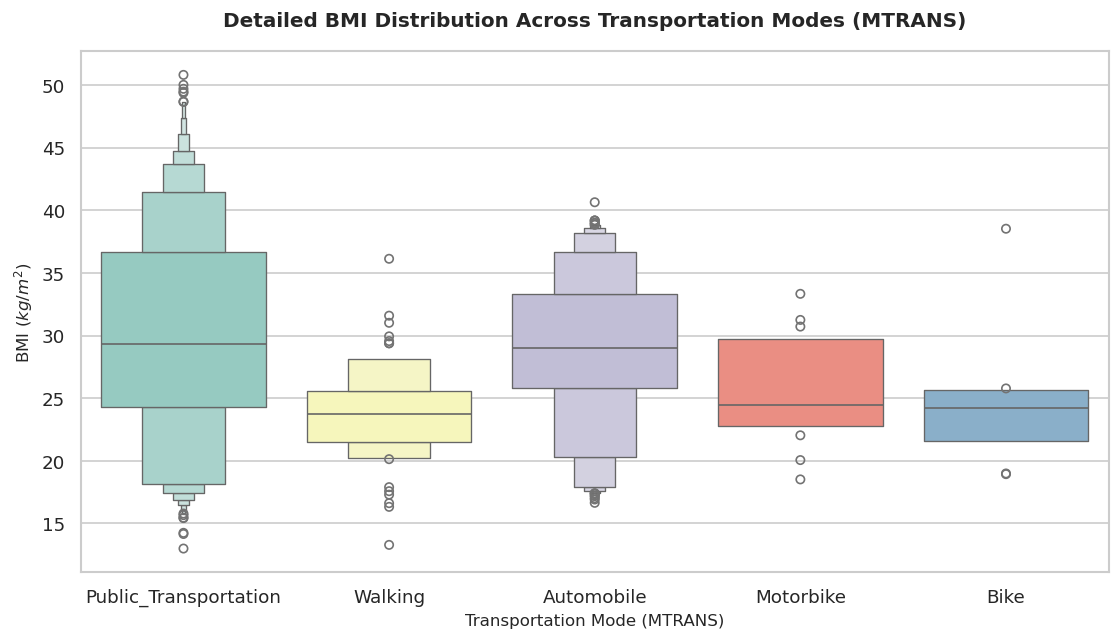

In [64]:
plt.figure(figsize=(9.5, 5.5))

sns.boxenplot(
    data=obesity_plot,
    x="MTRANS",
    y="BMI",
    hue="MTRANS", 
    palette="Set3",
    legend=False,  
    linewidth=0.8,
)

plt.title(
    "Detailed BMI Distribution Across Transportation Modes (MTRANS)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Transportation Mode (MTRANS)", fontsize=10)
plt.ylabel("BMI ($kg/m^2$)", fontsize=10)
plt.xticks(rotation=0)

plt.tight_layout()
save_eda_chart()
plt.show()

5.4.6 Lifestyle Profile: Normal Weight vs. Obesity Type III

Updated: eda_graphs/chart_20.png


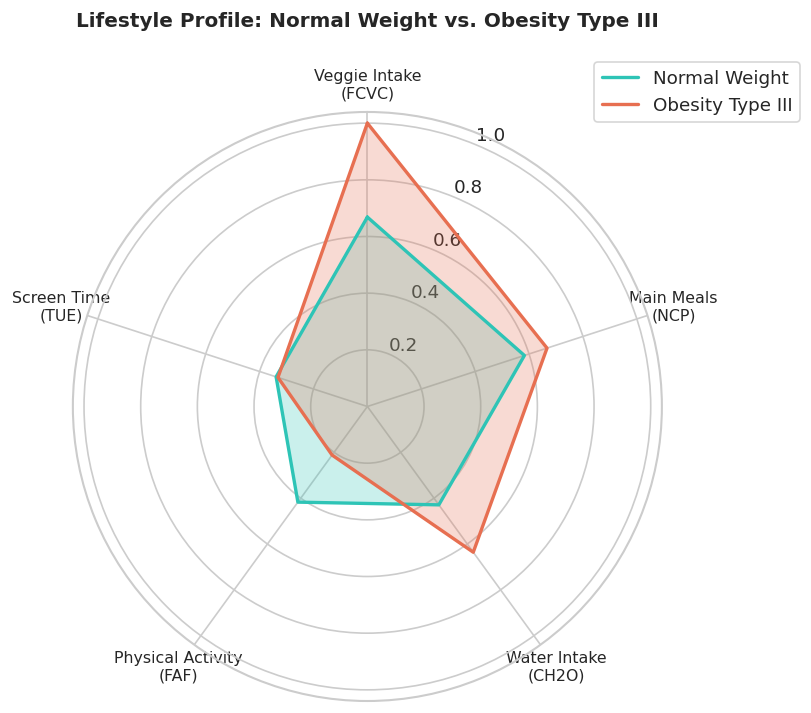

In [65]:
features = ["FCVC", "NCP", "CH2O", "FAF", "TUE"]

df_radar = obesity_plot[
    obesity_plot["NObeyesdad"]
    .astype(str)
    .str.contains("Normal|Type_III|Type III", case=False, na=False)
].copy()

scaler = MinMaxScaler()
df_radar[features] = scaler.fit_transform(df_radar[features])

df_radar["Weight_Group"] = df_radar["NObeyesdad"].apply(
    lambda x: "Obesity Type III" if "Type" in str(x) else "Normal Weight"
)

grouped = df_radar.groupby("Weight_Group")[features].mean()

labels = [
    "Veggie Intake\n(FCVC)",
    "Main Meals\n(NCP)",
    "Water Intake\n(CH2O)",
    "Physical Activity\n(FAF)",
    "Screen Time\n(TUE)",
]
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] 

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

values_normal = grouped.loc["Normal Weight"].tolist()
values_normal += values_normal[:1]
ax.plot(
    angles,
    values_normal,
    color="#2EC4B6",
    linewidth=2,
    label="Normal Weight",
)
ax.fill(angles, values_normal, color="#2EC4B6", alpha=0.25)

values_obese = grouped.loc["Obesity Type III"].tolist()
values_obese += values_obese[:1]
ax.plot(
    angles,
    values_obese,
    color="#E76F51",
    linewidth=2,
    label="Obesity Type III",
)
ax.fill(angles, values_obese, color="#E76F51", alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], labels, size=9.5)

plt.title(
    "Lifestyle Profile: Normal Weight vs. Obesity Type III",
    fontsize=12,
    fontweight="bold",
    pad=25,
)
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), frameon=True)

plt.tight_layout()
save_eda_chart()
plt.show()

6.0 Data Modelling

In this phase, machine learning models are developed and trained to predict obesity levels (Nobeyesdad). The dataset was partitioned into training and test sets, scaled using StandardScaler, and then evaluated using three different algorithms : K-Nearest Neighbours (KNN), Decision Tree(DT), and Support Vector Machine (SVM).

6.1 Data Preparation for Modelling

In [66]:
# Define Features and Target
X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1667, 17)
Testing Set: (417, 17)


6.2 Pairplot of Key Modelling Features

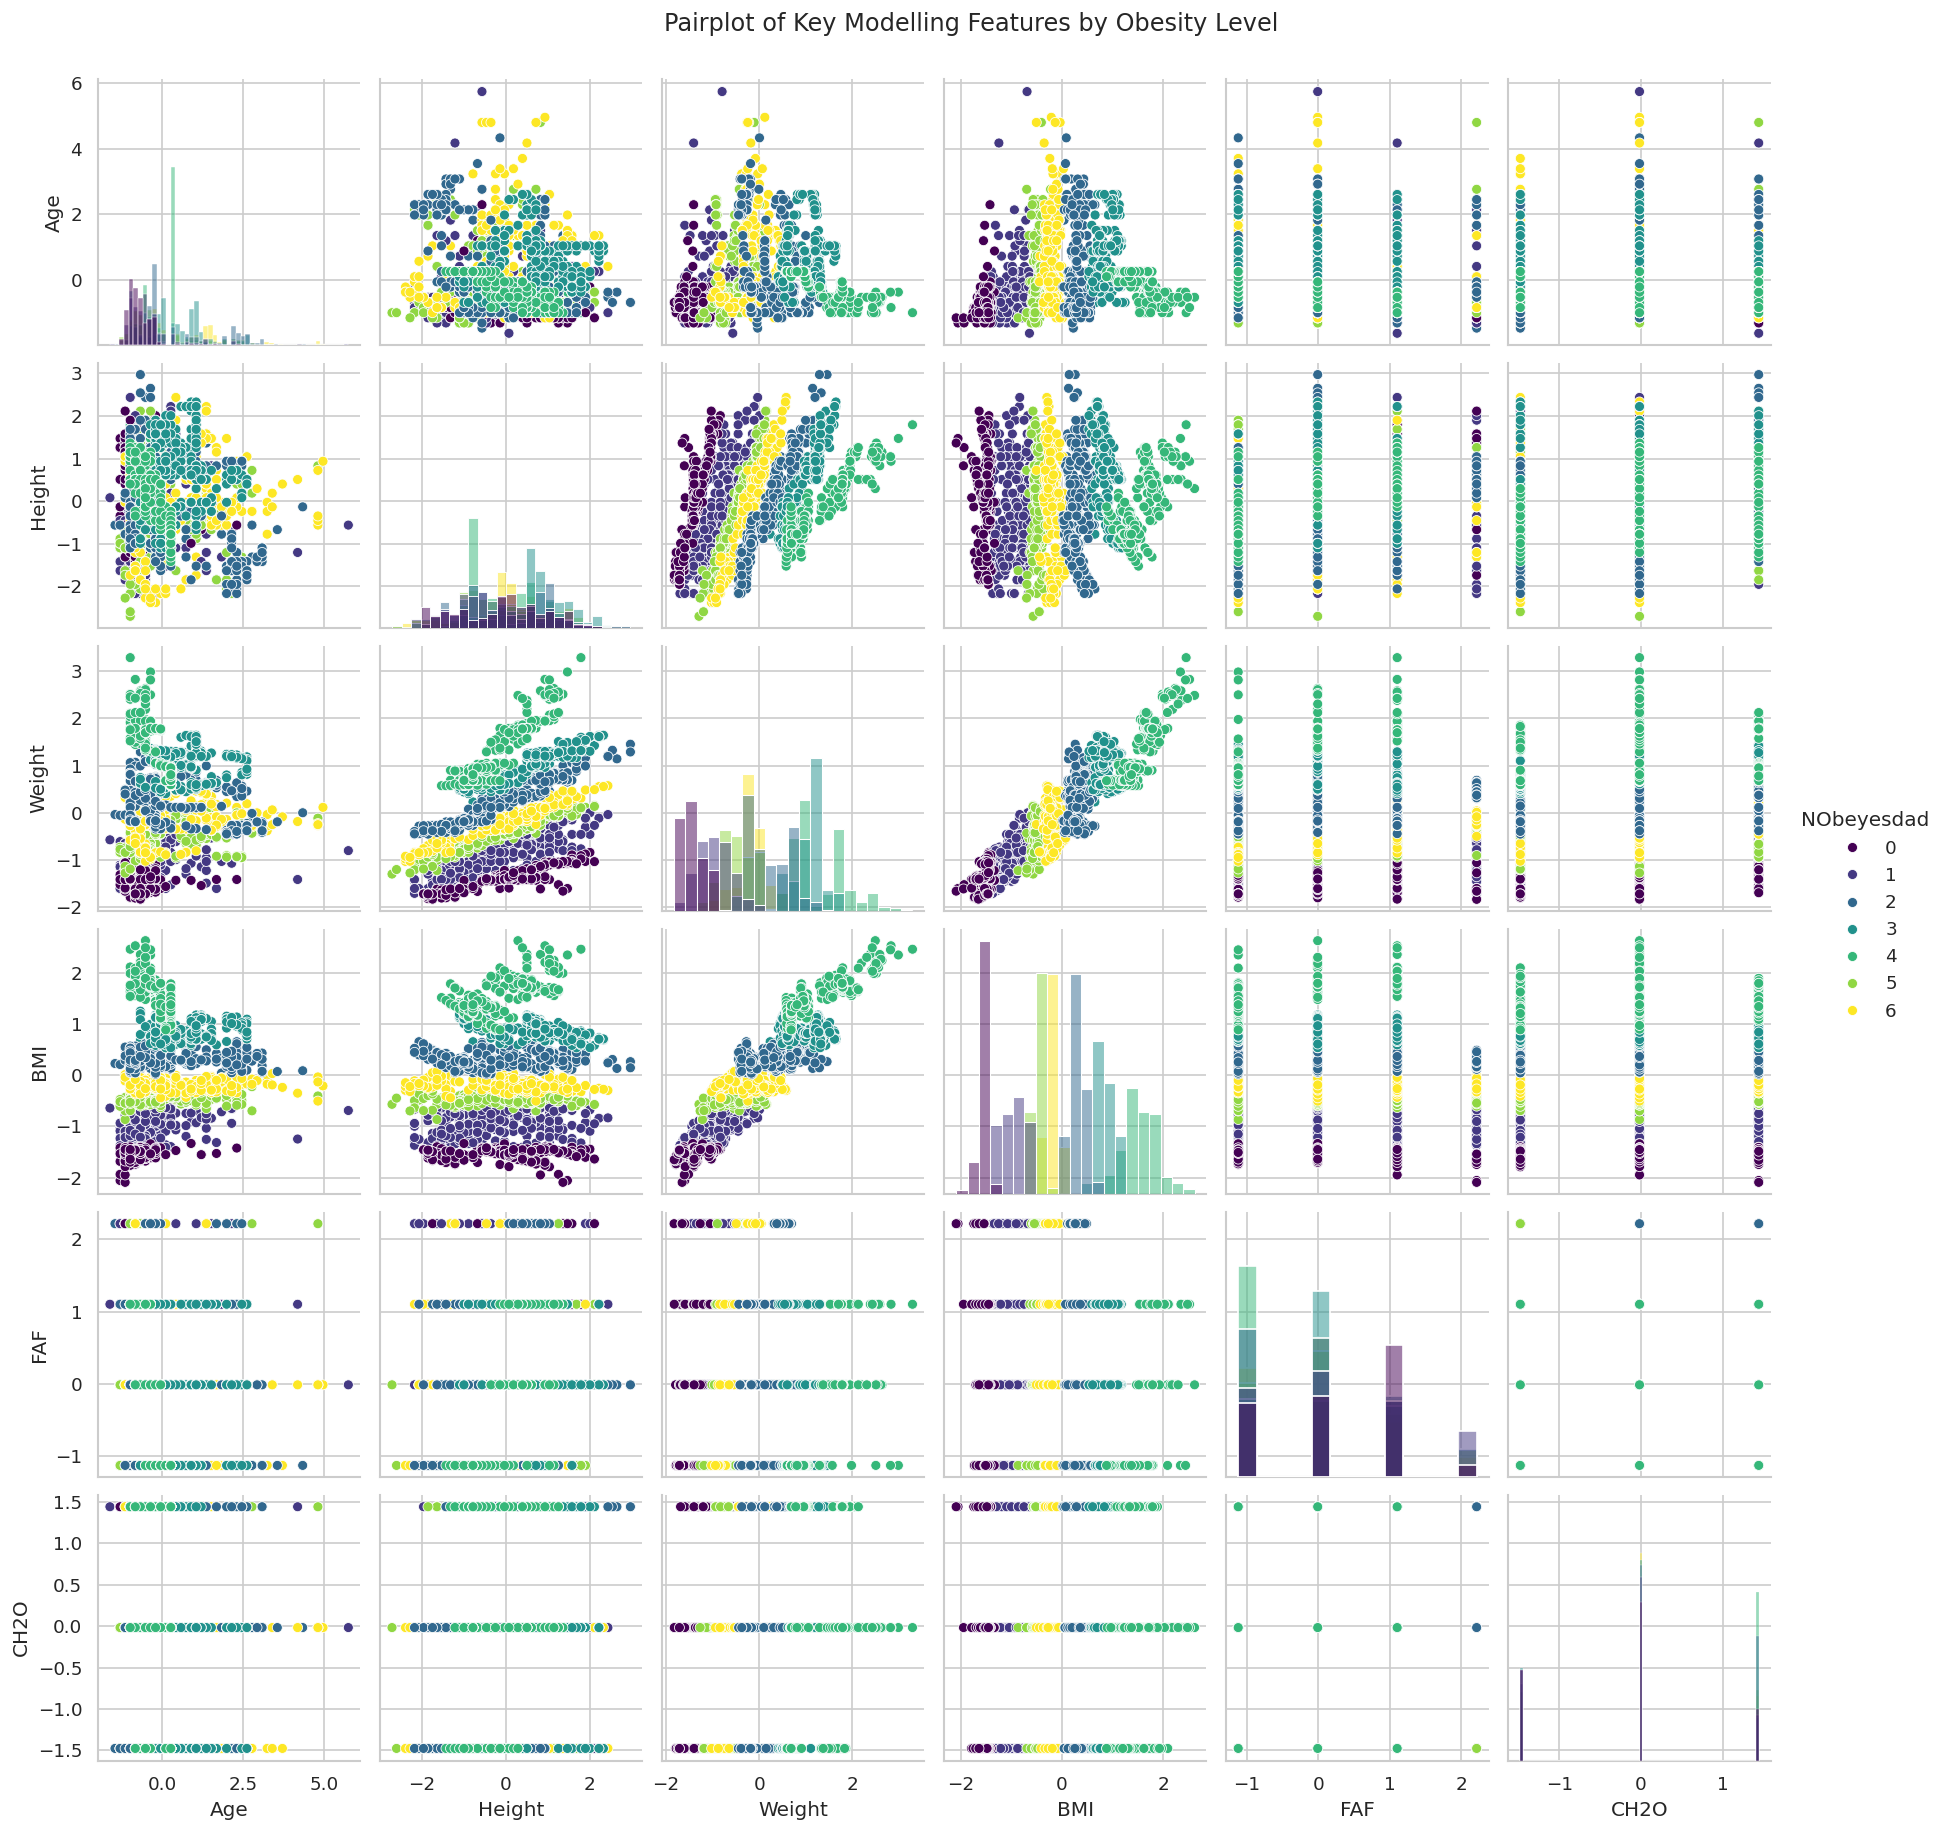

In [67]:
#Pairplot
pairplot_cols = ["Age", "Height", "Weight", "BMI", "FAF", "CH2O", "NObeyesdad"]

sns.pairplot(obesity[pairplot_cols], hue="NObeyesdad", palette="viridis", diag_kind="hist")
plt.suptitle("Pairplot of Key Modelling Features by Obesity Level", y=1.02)
plt.show()

6.3 Ordinal Severity Mapping

In [68]:
#Ordinal Severity Mapping
severity_map = {
    0: 0,  # Insufficient_Weight
    1: 1,  # Normal_Weight
    2: 2,  # Overweight_Level_I
    3: 3,  # Overweight_Level_II
    4: 4,  # Obesity_Type_I
    5: 5,  # Obesity_Type_II
    6: 6,  # Obesity_Type_III
}

y_test_severity = y_test.copy() 

6.6 K-Nearest Neighbour (KNN)

K-Nearest Neighbors (KNN) is a classification algorithm that predicts the class of a new observation based on the majority class of its nearest neighbours. It is suitable for obesity classification because similar individuals tend to share similar obesity levels.



6.6.1 5-Fold Cross Validation

In [69]:
knn = KNeighborsClassifier(n_neighbors=5)

# 5-Fold Cross-Validation on the training set
knn_cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
print("KNN Cross-Validation Scores:", knn_cv_scores)
print("KNN Mean CV Accuracy:", round(knn_cv_scores.mean(), 4))

knn_baseline_cv_scores = knn_cv_scores.copy()

# Fit on the full training set and evaluate on the held-out test set
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)


KNN Cross-Validation Scores: [0.82634731 0.77844311 0.76576577 0.83483483 0.77477477]
KNN Mean CV Accuracy: 0.796


6.6.2 Hyperparameter Tuning for KNN (GridSearchCV)


In [70]:
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2]
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring="accuracy"
)

knn_grid.fit(X_train_scaled, y_train)

print("Best n_neighbors:", knn_grid.best_params_["n_neighbors"])
print("Best CV Accuracy:", round(knn_grid.best_score_, 4))

# Replace the baseline KNN with the tuned model for the rest of the evaluation
knn = knn_grid.best_estimator_
knn_cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

print("Tuned KNN Mean CV Accuracy:", round(knn_cv_scores.mean(), 4))

Best n_neighbors: 7
Best CV Accuracy: 0.8668
Tuned KNN Mean CV Accuracy: 0.8668


6.6.3 Baseline vs Tuned Accuracy Comparison

To further illustrate the impact of hyperparameter tuning, the mean cross-validation accuracy of each model before tuning (using default hyperparameters) was compared against its mean cross-validation accuracy after tuning with GridSearchCV. Since SVM did not have an explicit default-parameter baseline computed earlier (only a manual C-value experiment), a baseline SVM model using scikit-learn's default settings (kernel='rbf', C=1.0) was evaluated using the same 5-fold cross-validation procedure applied to KNN and Decision Tree, ensuring a fair and consistent comparison across all three models.

In [71]:
baseline_vs_tuned = pd.DataFrame({
    "Model": ["KNN"],
    "Baseline CV Accuracy": [
        knn_baseline_cv_scores.mean(),
    ],
    "Tuned CV Accuracy": [
        knn_grid.best_score_,
    ]
})

baseline_vs_tuned

,Model,Baseline CV Accuracy,Tuned CV Accuracy
0,KNN,0.796033,0.866812


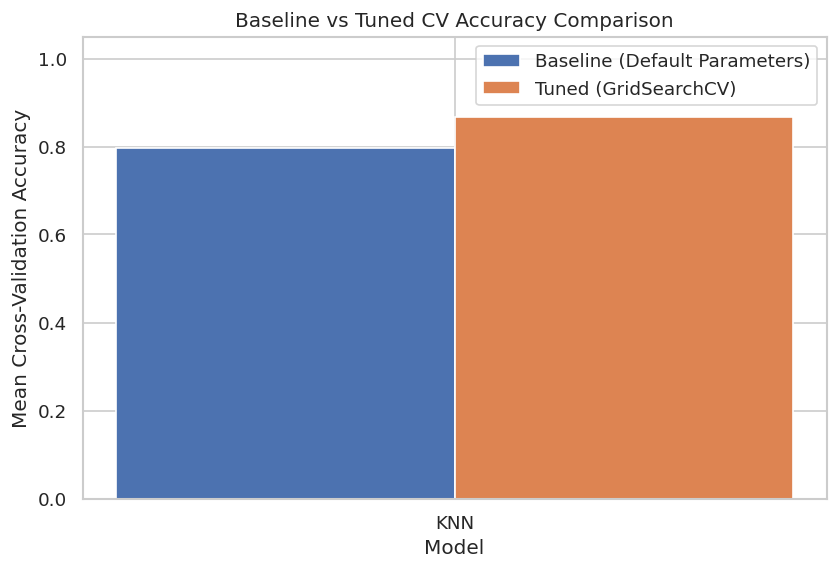

In [72]:
x = np.arange(len(baseline_vs_tuned))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, baseline_vs_tuned["Baseline CV Accuracy"], width, label="Baseline (Default Parameters)")
plt.bar(x + width/2, baseline_vs_tuned["Tuned CV Accuracy"], width, label="Tuned (GridSearchCV)")

plt.xticks(x, baseline_vs_tuned["Model"])
plt.title("Baseline vs Tuned CV Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.ylim(0, 1.05)
plt.legend()

plt.savefig("baseline_vs_tuned_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

6.7 Decision Tree

Decision Tree is a supervised learning algorithm that classifies observations by splitting the dataset into decision rules. It is highly interpretable and can capture nonlinear relationships among variables.



6.7.1 5-Fold Corss Validation

In [73]:
dt = DecisionTreeClassifier(random_state=42)

# 5-Fold Cross-Validation on the training set
dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
print("Decision Tree Cross-Validation Scores:", dt_cv_scores)
print("Decision Tree Mean CV Accuracy:", round(dt_cv_scores.mean(), 4))

dt_baseline_cv_scores = dt_cv_scores.copy()

# Fit on the full training set and evaluate on the held-out test set
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)


Decision Tree Cross-Validation Scores: [0.9760479  0.97904192 0.96096096 0.98498498 0.97297297]
Decision Tree Mean CV Accuracy: 0.9748


6.7.2 Hyperparameter Tuning for Decision Tree (GridSearchCV)



In [74]:
dt_param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [10, 15, 20, 25, None],
    "min_samples_split": [2, 3, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"],
    "ccp_alpha": [0.0, 0.0001, 0.001]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy"
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best CV Accuracy:", round(dt_grid.best_score_, 4))

# Replace the baseline Decision Tree with the tuned model for the rest of the evaluation
dt = dt_grid.best_estimator_
dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Tuned Decision Tree Mean CV Accuracy:", round(dt_cv_scores.mean(), 4))

Best Parameters: {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 0.9778
Tuned Decision Tree Mean CV Accuracy: 0.9778


6.7.3 Baseline vs Tuned Accuracy Comparison

In [75]:
baseline_vs_tuned = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Baseline CV Accuracy": [
        dt_baseline_cv_scores.mean(),
    ],
    "Tuned CV Accuracy": [
        dt_grid.best_score_,
    ]
})

baseline_vs_tuned

,Model,Baseline CV Accuracy,Tuned CV Accuracy
0,Decision Tree,0.974802,0.977798


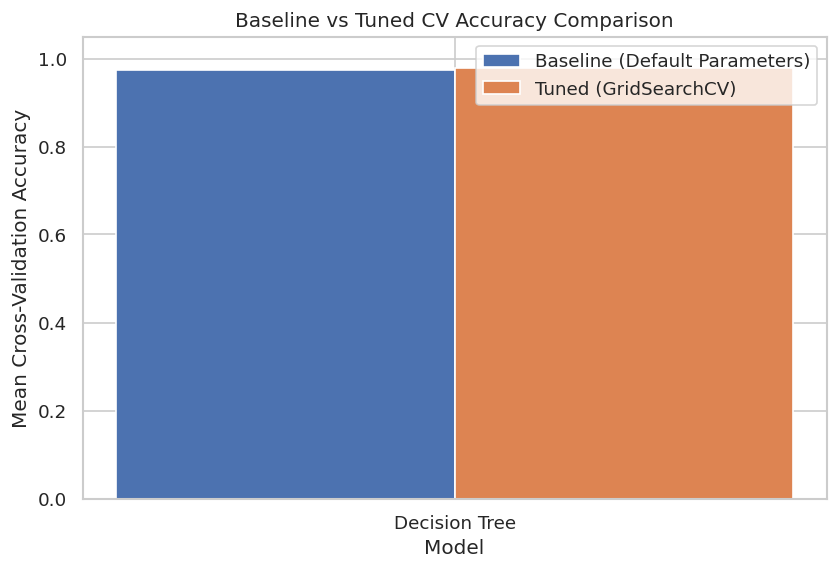

In [76]:
x = np.arange(len(baseline_vs_tuned))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, baseline_vs_tuned["Baseline CV Accuracy"], width, label="Baseline (Default Parameters)")
plt.bar(x + width/2, baseline_vs_tuned["Tuned CV Accuracy"], width, label="Tuned (GridSearchCV)")

plt.xticks(x, baseline_vs_tuned["Model"])
plt.title("Baseline vs Tuned CV Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.ylim(0, 1.05)
plt.legend()

plt.savefig("baseline_vs_tuned_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

6.7.4 Feature Importance (Decision Tree)

Taking all the evaluation results into account, the Decision Tree and SVM are considered the two best-performing models for this obesity classification task, with the Decision Tree holding a slight advantage in cross-validation accuracy while offering the added benefit of interpretability through feature importance analysis. SVM remains a strong and competitive alternative, particularly given its identical testing accuracy and RMSE. KNN, despite improving considerably after hyperparameter tuning, remains the weakest model overall and is therefore considered the least suitable choice for deployment in this study.

In [77]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":dt.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
16,BMI,0.793066
0,Gender,0.168085
3,Weight,0.016843
15,MTRANS,0.006295
1,Age,0.004331
7,NCP,0.003721
11,SCC,0.002658
12,FAF,0.001640
2,Height,0.001418
5,FAVC,0.001098


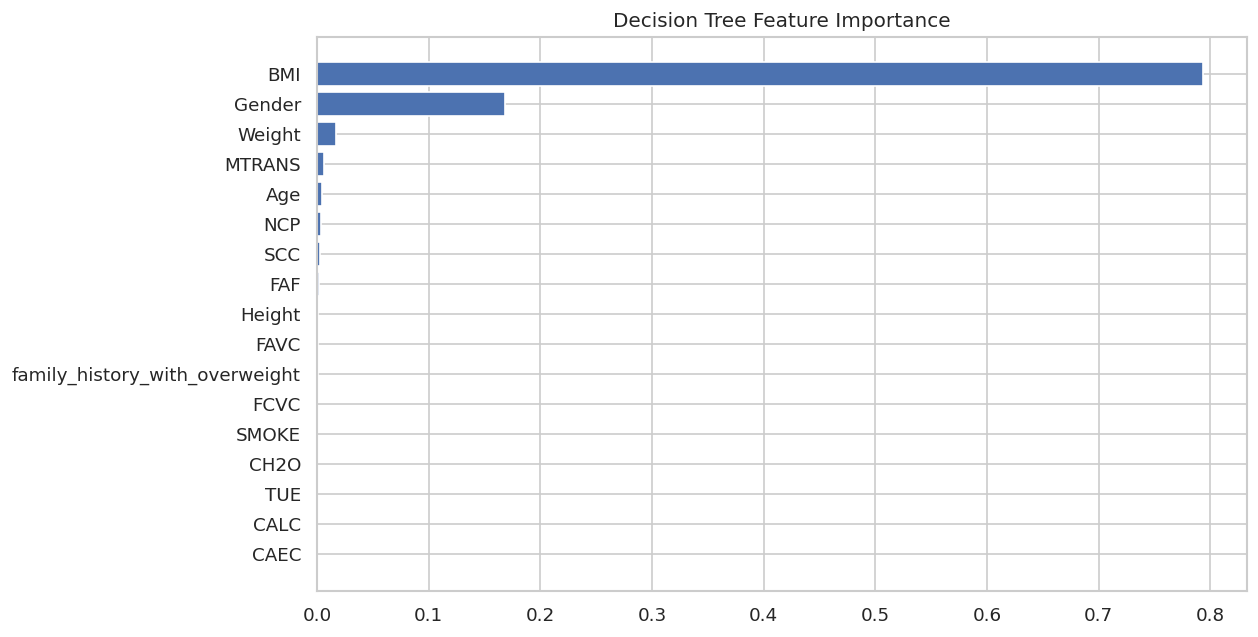

In [78]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Decision Tree Feature Importance")

plt.gca().invert_yaxis()

plt.show()

6.7.5 Permutation Importance

In [79]:
# Permutation Importance for Decision Tree
dt_perm = permutation_importance(
    dt,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

dt_perm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_perm.importances_mean
}).sort_values(by="Importance", ascending=False)

dt_perm_importance

,Feature,Importance
16,BMI,0.763869
3,Weight,0.187770
0,Gender,0.146123
7,NCP,0.004157
4,family_history_with_overweight,0.003197
15,MTRANS,0.003118
12,FAF,0.002078
11,SCC,0.000719
2,Height,0.000000
6,FCVC,0.000000


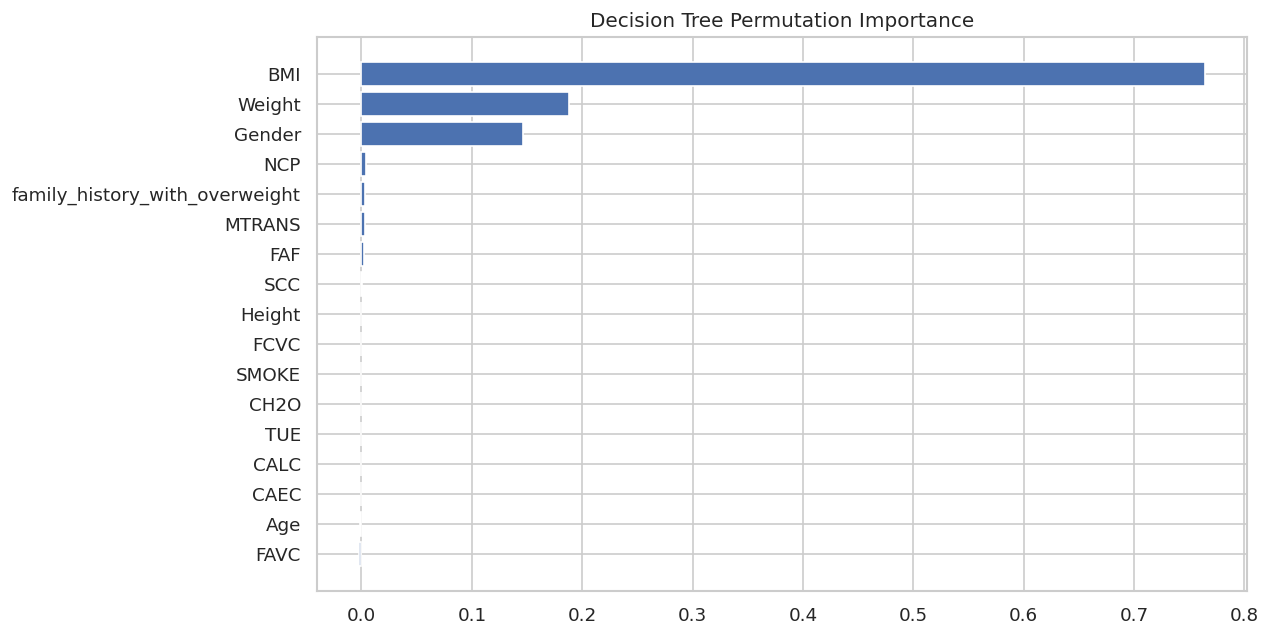

In [80]:
plt.figure(figsize=(10,6))

plt.barh(dt_perm_importance["Feature"], dt_perm_importance["Importance"])

plt.title("Decision Tree Permutation Importance")

plt.gca().invert_yaxis()

plt.show()

6.8 Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised learning algorithm that finds the optimal boundary (hyperplane) that best separates the classes. 

6.8.1 5-Fold Cross Validation

In [81]:
svm = SVC()  # baseline: default hyperparameters (kernel='rbf', C=1.0)

# 5-Fold Cross-Validation on the training set
svm_cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=5)
print("SVM Cross-Validation Scores:", svm_cv_scores)
print("SVM Mean CV Accuracy:", round(svm_cv_scores.mean(), 4))

# Fit on the full training set and evaluate on the held-out test set
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

# Snapshot the baseline CV scores now, before svm_cv_scores gets overwritten
# by the tuned model further down (see 5.6.2 Hyperparameter Tuning)
svm_baseline_cv_scores = svm_cv_scores.copy()

SVM Cross-Validation Scores: [0.91317365 0.8502994  0.87687688 0.93693694 0.88888889]
SVM Mean CV Accuracy: 0.8932


6.8.2 Effect of the C Parameter 


In [82]:
for c_value in [0.1, 1, 10, 100]:
    svc_test = SVC(kernel="rbf", C=c_value).fit(X_train_scaled, y_train)
    train_acc = svc_test.score(X_train_scaled, y_train)
    test_acc = svc_test.score(X_test_scaled, y_test)
    print(f"C={c_value:<6} Train Accuracy: {train_acc:.4f}   Test Accuracy: {test_acc:.4f}")

C=0.1    Train Accuracy: 0.7798   Test Accuracy: 0.7506
C=1      Train Accuracy: 0.9610   Test Accuracy: 0.9209
C=10     Train Accuracy: 0.9994   Test Accuracy: 0.9472
C=100    Train Accuracy: 1.0000   Test Accuracy: 0.9472


6.8.3 Hyperparameter Tuning for SVM (GridSearchCV)

In [83]:
svm_param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "poly"],
    "gamma": ["scale"],
    "degree": [2, 3]
}
svm_grid = GridSearchCV(
    SVC(),
    param_grid=svm_param_grid,
    cv=5,
    scoring="accuracy"
)

svm_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best CV Accuracy:", round(svm_grid.best_score_, 4))

svm = svm_grid.best_estimator_
svm_cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=5)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

print("SVM Mean CV Accuracy:", round(svm_cv_scores.mean(), 4))

Best Parameters: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Accuracy: 0.964
SVM Mean CV Accuracy: 0.964


6.8.4 Baseline Vs Tune Accuracy Training

In [84]:
baseline_vs_tuned = pd.DataFrame({
    "Model": ["SVM"],
    "Baseline CV Accuracy": [
        svm_baseline_cv_scores.mean()
    ],
    "Tuned CV Accuracy": [
        svm_grid.best_score_
    ]
})

baseline_vs_tuned

,Model,Baseline CV Accuracy,Tuned CV Accuracy
0,SVM,0.893235,0.964009


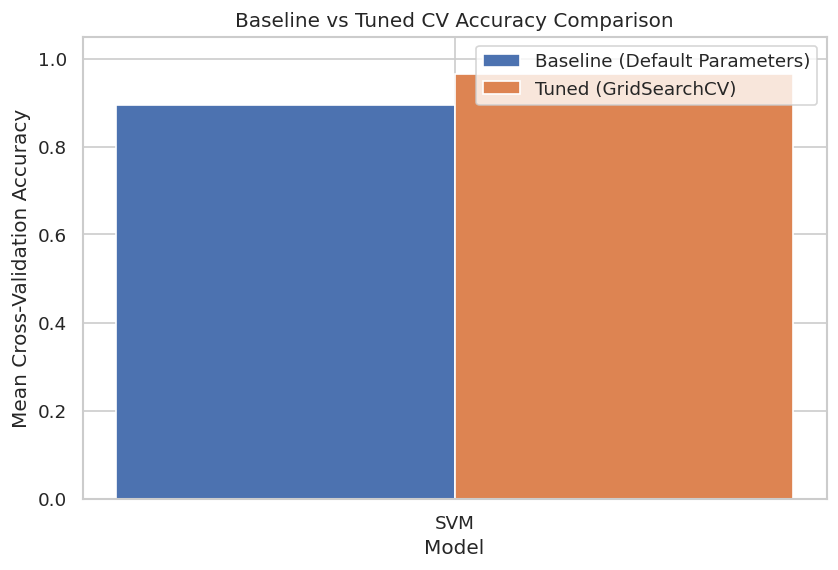

In [85]:
x = np.arange(len(baseline_vs_tuned))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, baseline_vs_tuned["Baseline CV Accuracy"], width, label="Baseline (Default Parameters)")
plt.bar(x + width/2, baseline_vs_tuned["Tuned CV Accuracy"], width, label="Tuned (GridSearchCV)")

plt.xticks(x, baseline_vs_tuned["Model"])
plt.title("Baseline vs Tuned CV Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.ylim(0, 1.05)
plt.legend()

plt.savefig("baseline_vs_tuned_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

6.8.5 Permutation Importance

In [86]:
# Permutation Importance for SVM (uses the scaled test features, since SVM was trained on scaled data)
svm_perm = permutation_importance(
    svm,
    X_test_scaled,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

svm_perm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": svm_perm.importances_mean
}).sort_values(by="Importance", ascending=False)

svm_perm_importance

,Feature,Importance
16,BMI,0.635731
3,Weight,0.574660
0,Gender,0.132454
2,Height,0.130456
7,NCP,0.023102
1,Age,0.021183
5,FAVC,0.008873
8,CAEC,0.006715
14,CALC,0.004716
12,FAF,0.003837


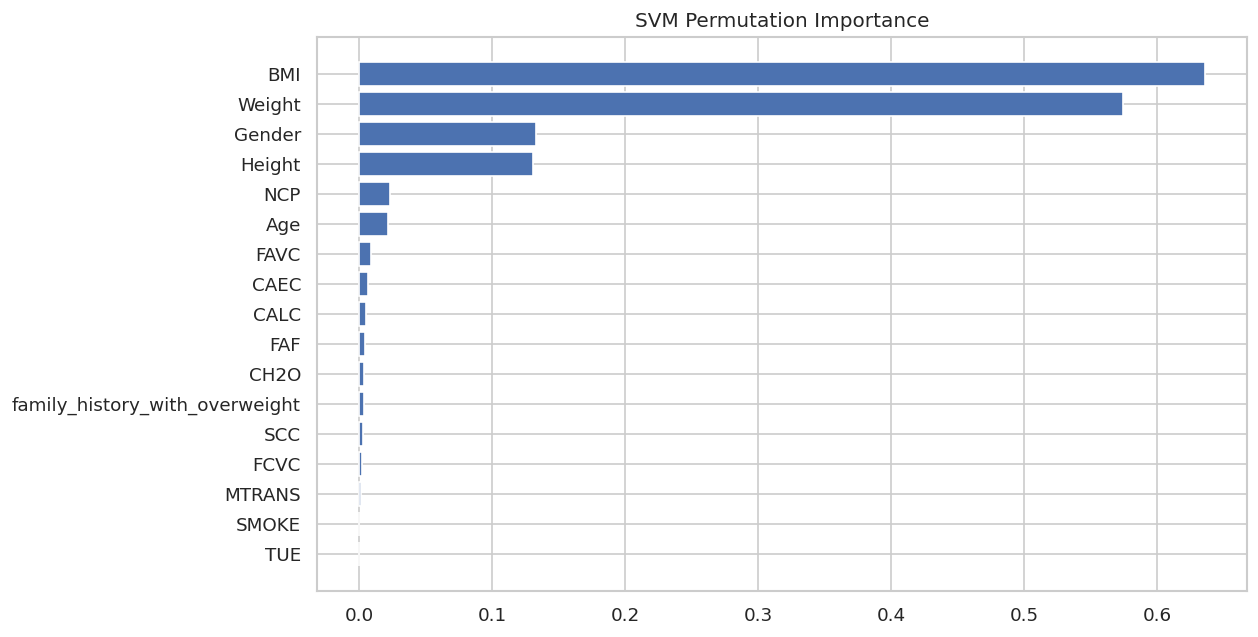

In [87]:
plt.figure(figsize=(10,6))

plt.barh(svm_perm_importance["Feature"], svm_perm_importance["Importance"])

plt.title("SVM Permutation Importance")

plt.gca().invert_yaxis()

plt.show()

7.0 Modelling Evaluation

After all three models were trained and tuned, their performance was evaluated and compared on the held-out testing set using multiple evaluation metrics, including accuracy, Root Mean Squared Error (RMSE), classification reports and confusion matrices. Evaluating the models using several complementary metrics provides a more complete understanding of their strengths and weaknesses, rather than relying on a single measure of performance.

7.1 Accuracy

In [88]:
knn_accuracy = accuracy_score(y_test, knn_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)
svm_accuracy = accuracy_score(y_test, svm_pred)

print("KNN Accuracy:", round(knn_accuracy,4))
print("Decision Tree Accuracy:", round(dt_accuracy,4))
print("SVM Accuracy:", round(svm_accuracy,4))

KNN Accuracy: 0.8969
Decision Tree Accuracy: 0.9688
SVM Accuracy: 0.9688


7.2 RMSE Calculation

In [89]:
# The hypothesis of each model turn into severity rank
knn_pred_severity = pd.Series(knn_pred).map(severity_map)
dt_pred_severity  = pd.Series(dt_pred).map(severity_map)
svm_pred_severity = pd.Series(svm_pred).map(severity_map)

knn_rmse = np.sqrt(mean_squared_error(y_test_severity, knn_pred_severity))
dt_rmse  = np.sqrt(mean_squared_error(y_test_severity, dt_pred_severity))
svm_rmse = np.sqrt(mean_squared_error(y_test_severity, svm_pred_severity))

print("KNN RMSE:", round(knn_rmse, 4))
print("Decision Tree RMSE:", round(dt_rmse, 4))
print("SVM RMSE:", round(svm_rmse, 4))

KNN RMSE: 1.033
Decision Tree RMSE: 0.4594
SVM RMSE: 0.3729


7.3 Classification Report

In [90]:
print("========== KNN ==========")
print(classification_report(y_test, knn_pred))

print("========== Decision Tree ==========")
print(classification_report(y_test, dt_pred))

print("========== SVM ==========")
print(classification_report(y_test, svm_pred))

========== KNN ==========
              precision    recall  f1-score   support

           0       0.85      0.96      0.90        53
           1       0.88      0.54      0.67        56
           2       0.91      0.96      0.93        70
           3       0.92      1.00      0.96        60
           4       1.00      1.00      1.00        65
           5       0.86      0.89      0.88        55
           6       0.84      0.90      0.87        58

    accuracy                           0.90       417
   macro avg       0.89      0.89      0.89       417
weighted avg       0.90      0.90      0.89       417

========== Decision Tree ==========
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        53
           1       0.95      0.93      0.94        56
           2       1.00      0.94      0.97        70
           3       0.94      1.00      0.97        60
           4       1.00      1.00      1.00        65
           5    

7.4 Confusion Matrix

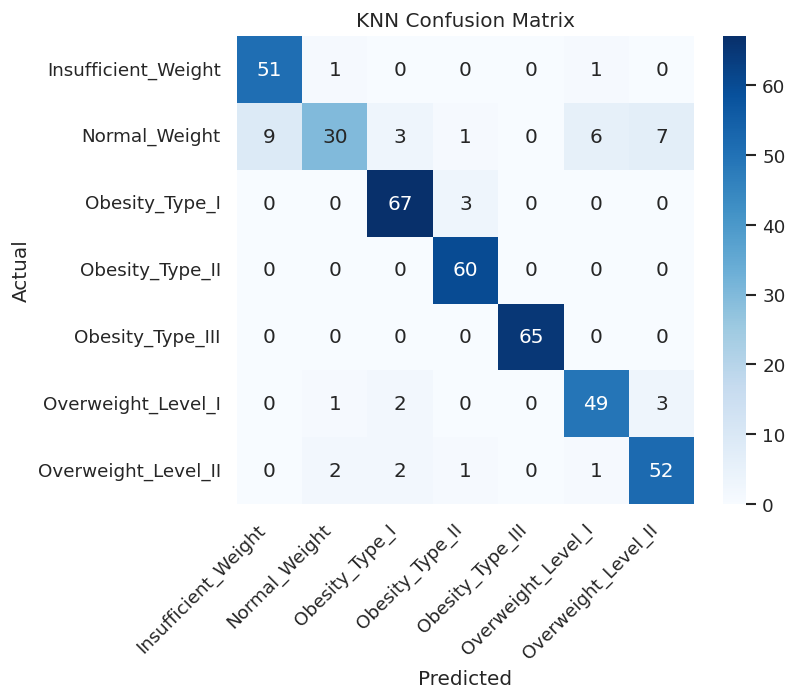

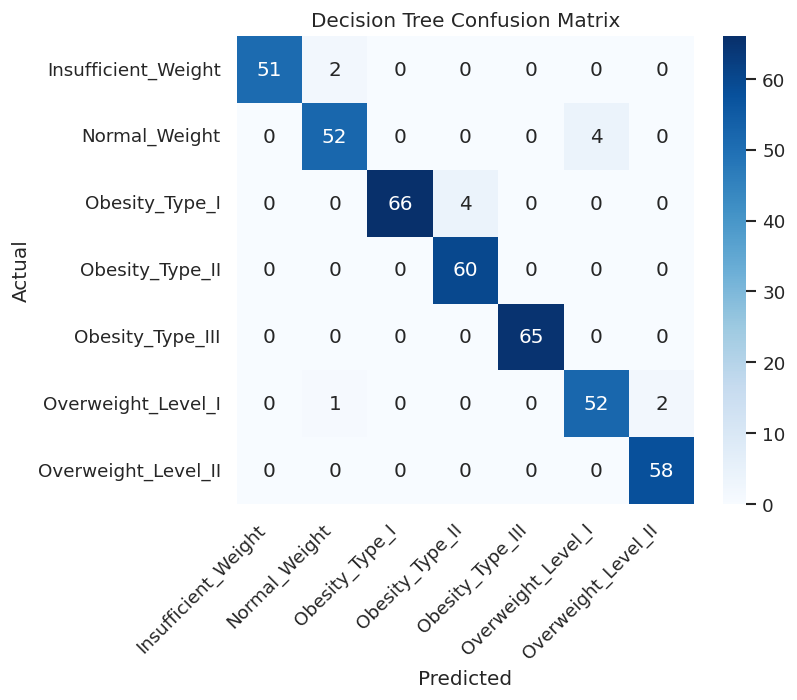

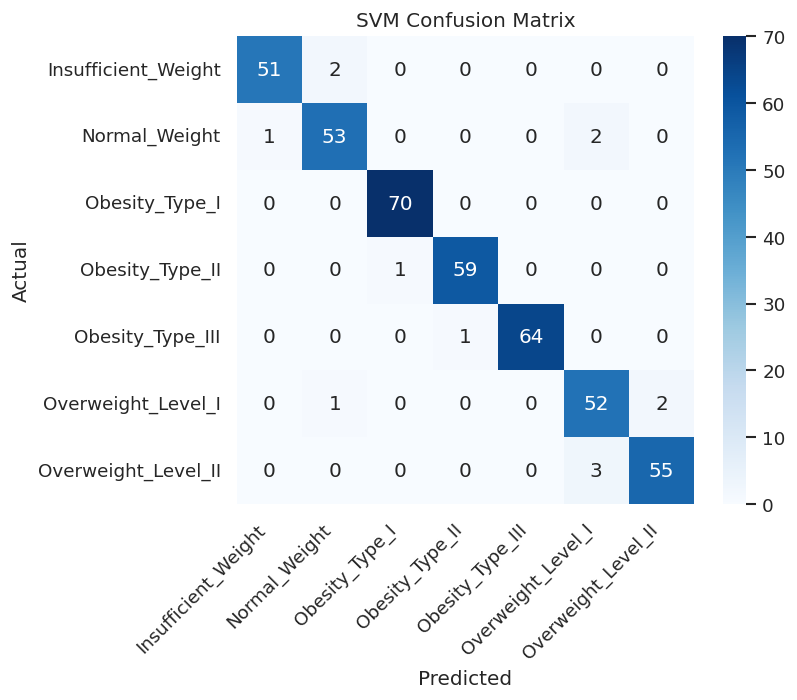

In [91]:
models = {
    "KNN": knn_pred,
    "Decision Tree": dt_pred,
    "SVM": svm_pred
}

# Store each model's confusion matrix for reuse in the Error Analysis section below
confusion_matrices = {}

for name, prediction in models.items():

    cm = confusion_matrix(y_test, prediction)
    confusion_matrices[name] = cm

    plt.figure(figsize=(7,6))

    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=target_encoder.classes_,
                yticklabels=target_encoder.classes_)

    plt.title(name + " Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    plt.show()

7.5 Model Comparison 

To summarise and directly compare the performance of the three models, a comparison table was constructed containing the mean cross-validation accuracy and the testing accuracy of each model, and the results were further visualised using a grouped bar chart. As shown in the output, the Decision Tree achieved the highest cross-validation accuracy of 0.9778, followed closely by SVM at 0.9640, while KNN recorded the lowest cross-validation accuracy of 0.8688. On the testing set, the Decision Tree and SVM achieved an identical accuracy of 0.9688, while KNN again recorded the lowest testing accuracy of 0.8969.


In [92]:
knn_fl = f1_score(y_test, knn_pred, average ="weighted")
dt_fl = f1_score(y_test, dt_pred, average ="weighted")
svm_fl = f1_score(y_test, svm_pred, average ="weighted")

comparison = pd.DataFrame({

    "Model":[
        "KNN",
        "Decision Tree",
        "SVM"
    ],

    "CV Accuracy":[
        knn_cv_scores.mean(),
        dt_cv_scores.mean(),
        svm_cv_scores.mean()
    ],

    "Test Accuracy":[
        knn_accuracy,
        dt_accuracy,
        svm_accuracy
    ],
    
    "Weighted F1-Score":[
        knn_fl,
        dt_fl,
        svm_fl
    ]

})

comparison = comparison.sort_values(
    by="Test Accuracy",
    ascending=False
)

comparison

,Model,CV Accuracy,Test Accuracy,Weighted F1-Score
1,Decision Tree,0.977798,0.968825,0.968833
2,SVM,0.964009,0.968825,0.968909
0,KNN,0.866812,0.896882,0.890419


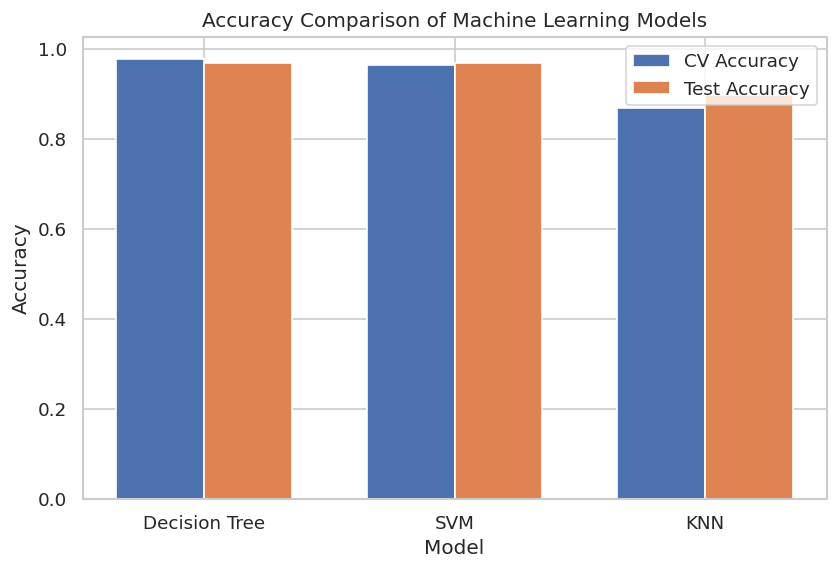

In [93]:
x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, comparison["CV Accuracy"], width, label="CV Accuracy")
plt.bar(x + width/2, comparison["Test Accuracy"], width, label="Test Accuracy")

plt.xticks(x, comparison["Model"])
plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

6.5 Error Analysis : Top Misclassification

To better understand where each model struggles, the confusion matrices above were used to identify the specific pairs of actual vs predicted classes that were most frequently confused. This provides concrete evidence to discuss alongside the confusion matrix visualisations, rather than relying on a visual reading of the heatmap alone.

In [94]:
class_names = target_encoder.classes_

def top_misclassifications(cm, class_names, top_n=3):
    """Return the top_n most frequent (actual, predicted) error pairs for a confusion matrix."""
    rows = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:
                rows.append((class_names[i], class_names[j], cm[i, j]))

    result = pd.DataFrame(rows, columns=["Actual", "Predicted As", "Count"])
    result = result.sort_values(by="Count", ascending=False).head(top_n).reset_index(drop=True)
    return result

for name, cm in confusion_matrices.items():
    print(f"========== {name}: Top Misclassifications ==========")
    print(top_misclassifications(cm, class_names, top_n=3).to_string(index=False))
    print()

========== KNN: Top Misclassifications ==========
       Actual        Predicted As  Count
Normal_Weight Insufficient_Weight      9
Normal_Weight Overweight_Level_II      7
Normal_Weight  Overweight_Level_I      6

========== Decision Tree: Top Misclassifications ==========
             Actual       Predicted As  Count
      Normal_Weight Overweight_Level_I      4
     Obesity_Type_I    Obesity_Type_II      4
Insufficient_Weight      Normal_Weight      2

========== SVM: Top Misclassifications ==========
             Actual       Predicted As  Count
Overweight_Level_II Overweight_Level_I      3
Insufficient_Weight      Normal_Weight      2
      Normal_Weight Overweight_Level_I      2



8.0 Deployment

8.1 Model Deployment

In [95]:
# Save the best models
joblib.dump(dt_grid.best_estimator_, "decision_tree.pkl")
joblib.dump(knn_grid.best_estimator_, "knn.pkl")
joblib.dump(svm_grid.best_estimator_, "svm.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

joblib.dump(target_encoder, "target_encoder.pkl")

print("target_encoder.pkl saved successfully!")

print("All models saved successfully!")

target_encoder.pkl saved successfully!
All models saved successfully!


In [96]:
# Load the saved model and preprocessing objects
loaded_model = joblib.load("decision_tree.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_target_encoder = joblib.load("target_encoder.pkl")

# Simulate a new, unseen participant's data
# (columns must match X: Gender, Age, Height, Weight, family_history_with_overweight,
#  FAVC, FCVC, NCP, CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS, BMI)
new_participant = pd.DataFrame([{
    "Gender": 1,                # Male
    "Age": 28.0,
    "Height": 1.75,
    "Weight": 95.0,
    "family_history_with_overweight": 1,
    "FAVC": 1,
    "FCVC": 2.0,
    "NCP": 3.0,
    "CAEC": 2.0,
    "SMOKE": 0,
    "CH2O": 2.0,
    "SCC": 0,
    "FAF": 0.0,
    "TUE": 1.0,
    "CALC": 1.0,
    "MTRANS": 0,
    "BMI": 95.0 / (1.75 ** 2)
}])

prediction = loaded_model.predict(new_participant)
predicted_class = loaded_target_encoder.inverse_transform(prediction)

print("Predicted Obesity Level:", predicted_class[0])

Predicted Obesity Level: Obesity_Type_III
